In [1]:
# ==========================================
# 1. 环境配置与导入
# ==========================================
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import random
import json
import logging
# === 引入实际实验所用的检索引擎 ===
import sys
import os
# 确保能够扫描到项目根目录的模块
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..'))) 

try:
    from retriever.engine import DualMetricRetriever
except ImportError:
    # 如果您的 engine.py 放在同级或其他目录，请根据实际情况调整导入路径
    from engine import DualMetricRetriever
# 1. 添加项目根目录
sys.path.append(os.getcwd())

# 2. 添加配置文件的路径
config_path = os.path.join(os.getcwd(), "Datasets", "processed_datasets")
if config_path not in sys.path:
    sys.path.append(config_path)

# 导入项目模块
from corrector.trainer import CorrectionTrainer
from corrector.corrector_model import (
    DeepTransformerCorrector, AttentionCorrector, LinearWeightedCorrector, 
    SimilarityWeightedCorrector, WeightedBaselineCorrector, LearnableWeightedCorrector,
    MLPCorrector, ZeroCorrector, StandardTransformerCorrector, LightWeightMetaCorrector,
    DualSourceFusionCorrector, DualSourceSetMLPCorrector, DualSourceGatedMLPCorrector
)
from utils.missing import fill_missing
from database.manager import SchoolwareDB

# 尝试导入数据集配置
try:
    from Datasets.processed_datasets.dataset_config import DATASET_GROUPS
    print("✅ 成功导入 DATASET_GROUPS 配置")
except ImportError:
    try:
        from Datasets.processed_datasets.dataset_config import DATASET_GROUPS
        print("✅ 成功导入 DATASET_GROUPS 配置 (from relative path)")
    except ImportError:
        print("❌ 无法导入 dataset_config.py，请检查路径！")
        DATASET_GROUPS = {}

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans' 
plt.rcParams['axes.unicode_minus'] = False
print("✅ 环境加载完成")

e:\anaconda3\envs\TS_HW2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 成功导入 DATASET_GROUPS 配置
✅ 环境加载完成


In [2]:
# ==========================================
# 2. 定义智能加载函数 (适配双重指纹)
# ==========================================

def scan_tsfm_directory(data_root, target_tsfm):
    """扫描指定 TSFM 的数据目录"""
    tsfm_dir = os.path.join(data_root, target_tsfm)
    if not os.path.exists(tsfm_dir):
        candidates = [d for d in os.listdir(data_root) if d.lower() == target_tsfm.lower()]
        if candidates:
            tsfm_dir = os.path.join(data_root, candidates[0])
            target_tsfm = candidates[0]
        else:
            raise FileNotFoundError(f"❌ 找不到 TSFM 目录: {tsfm_dir}")
            
    train_list, test_list = [], []
    for root, dirs, files in os.walk(tsfm_dir):
        for f in files:
            if f.endswith("_correction_data.pkl"):
                ds_name = f.replace('_correction_data.pkl', '').replace('.pkl', '')
                if "GE_" in ds_name or "Gift_Eval" in root:
                    test_list.append(ds_name)
                else:
                    train_list.append(ds_name)
    return list(set(train_list)), list(set(test_list)), target_tsfm

def get_corrector_model_instance(config):
    """根据配置实例化模型"""
    arch = config.get("corrector_arch")
    
    MODEL_MAP = {
        "standard_transformer": StandardTransformerCorrector,
        "similarity_weighted": SimilarityWeightedCorrector,
        "linear": LinearWeightedCorrector, 
        "mlp": MLPCorrector,
        "BSA1": WeightedBaselineCorrector, 
        "BSA2": LightWeightMetaCorrector,
        "learnable_weighted": LearnableWeightedCorrector, 
        "zero": ZeroCorrector,
        "deep_transformer": DeepTransformerCorrector,
        "attention": AttentionCorrector,
        "dual_source_fusion": DualSourceFusionCorrector,
        "dual_set_mlp": DualSourceSetMLPCorrector,
        "dual_gated_mlp": DualSourceGatedMLPCorrector,
    }
    
    if not arch:
        arch = config.get("model_type")
        if not arch and "std_tf" in str(config): arch = "std_tf"

    if arch not in MODEL_MAP:
        # 兼容性兜底
        if "n_head" in config or "num_heads" in config: 
            return StandardTransformerCorrector(config)
        raise ValueError(f"Unknown corrector architecture: {arch}")
    
    return MODEL_MAP[arch](config)

def load_single_tsfm_system(exp_dir, data_root="correction_datasets_double_res"):
    """
    🎯 核心接口：加载单 TSFM 实验系统 (支持 Dual-Source)
    """
    print(f"🚀 正在加载实验: {exp_dir}")
    
    # 1. 读取完整的超参数配置
    hp_path = os.path.join(exp_dir, "hyperparams.json")
    if not os.path.exists(hp_path):
        print("⚠️ 未找到 hyperparams.json，尝试推断配置...")
        model_config = {"corrector_arch": "dual_source_fusion", "d_model": 128} # 默认假定为新模型
    else:
        with open(hp_path, 'r') as f:
            model_config = json.load(f)
    print(f"✅ 已加载完整配置 (Arch={model_config.get('corrector_arch', 'Unknown')})")

    # 2. 推断环境信息
    path_parts = os.path.normpath(exp_dir).split(os.sep)
    try:
        target_tsfm = path_parts[-4] 
        encoder_type = path_parts[-3]
    except:
        print("⚠️ 路径解析失败，使用默认 TSFM/Encoder 设置")
        target_tsfm = "chronos_bolt_tiny"
        encoder_type = "advanced_hybrid_math"

    print(f"🕵️ 数据源推断: TSFM={target_tsfm} | Encoder={encoder_type}")

    # 3. 实例化模型
    model = get_corrector_model_instance(model_config)
    
    # 4. 加载权重
    ckpt_path = os.path.join(exp_dir, "best_model.pth")
    if os.path.exists(ckpt_path):
        print(f"📥 加载权重: best_model.pth")
        state_dict = torch.load(ckpt_path, map_location="cuda" if torch.cuda.is_available() else "cpu")
        model.load_state_dict(state_dict)
    else:
        print(f"⚠️ 警告: 未找到权重文件，使用随机初始化！")
        
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # 5. 准备数据加载器
    train_list, test_list, real_tsfm_name = scan_tsfm_directory(data_root, target_tsfm)

    # 动态设置 db_config
    if encoder_type == "units":
        output_dim = 128
        ckpt_path = "checkpoints\\units_x128_pretrain_checkpoint.pth"
    elif encoder_type == "advanced_hybrid_math":
        output_dim = 112
        ckpt_path = None
    else:
        output_dim = 128
        ckpt_path = None
        print(f"⚠️ Unknown encoder_type '{encoder_type}'; using default settings.")

    db_config = {
        "data_dir": data_root,
        "encoder_type": encoder_type,
        "context_len": 512,
        "output_dim": output_dim,
        "ckpt_path": ckpt_path
    }

    train_config = {
        "batch_size": 1,
        "train_datasets_list": train_list, 
        "test_datasets_list": test_list,
        "target_tsfm_filter": real_tsfm_name,
        "retrieval_scope": "cross_dataset",
        "max_samples_per_dataset": 650, 
        "max_test_samples_per_dataset": 100,
        "logger": None,
        # [关键] 传入 retrieval_alpha，默认为 0.5 (如果 config 里没有)
        "retrieval_alpha": model_config.get('retrieval_alpha', 0.5),
        "filter_by_freq": 1,  # 检索相同频率的邻居
        "filter_by_domain": 1,  # 检索相同领域
        
    }
    
    # 6. 初始化 Trainer
    print("⏳ 初始化数据加载器 (这可能需要几分钟)...")
    logging.getLogger("SingleTSFMGrid").setLevel(logging.ERROR)
    
    trainer = CorrectionTrainer(model, model_config, db_config, train_config)
    
    return trainer, model, real_tsfm_name, model_config

print("✅ 加载函数定义完成")

✅ 加载函数定义完成


In [3]:
# ==========================================
# 3. 执行系统加载
# ==========================================

# 👇 请修改为您实际的实验路径
# EXP_DIR = r"results\dual_source_experiment_0126\chronos_bolt_tiny\advanced_hybrid_math\dual_set_mlp\run_001_2d486f1a" dual_set_mlp\moirai_small
EXP_DIR = r"results\dual_source_experiment_0313_0\chronos_bolt_tiny\advanced_hybrid_math\dual_fusion_large\run_002_9ca24b23"
DATA_ROOT = "correction_datasets_double_res_0" # 确保指向包含 local_residuals 的新数据

if os.path.exists(EXP_DIR):
    trainer, model, target_model_name, hyperparams = load_single_tsfm_system(EXP_DIR, DATA_ROOT)
    
    CONFIG = {
        "CONTEXT_LEN": 512,
        "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
        "TOP_K": trainer.model_config.get('top_k', 50),
        "RETRIEVAL_SCOPE": "cross_dataset",
        "RETRIEVAL_ALPHA": hyperparams.get('retrieval_alpha', 0.5)
    }
    device = torch.device(CONFIG["DEVICE"])
    
    # 移动 Encoder 到 GPU
    if hasattr(trainer.db, 'encoder'):
        trainer.db.encoder.to(device)
    print(f"\n✅ 系统就绪! 训练样本: {len(trainer.train_samples)}")
    print(f"⚖️  Retrieval Alpha: {CONFIG['RETRIEVAL_ALPHA']}")
else:
    print(f"❌ 路径不存在: {EXP_DIR}")

🚀 正在加载实验: results\dual_source_experiment_0313_0\chronos_bolt_tiny\advanced_hybrid_math\dual_fusion_large\run_002_9ca24b23
✅ 已加载完整配置 (Arch=dual_source_fusion)
🕵️ 数据源推断: TSFM=chronos_bolt_tiny | Encoder=advanced_hybrid_math
📥 加载权重: best_model.pth
⏳ 初始化数据加载器 (这可能需要几分钟)...
🚀 [Trainer] Device: cuda | Patience: 10
🛠️ 误差检索度量机制: L2
🛠️ 初始化编码器: [advanced_hybrid_math]
🔍 模式 [CROSS_DATASET] 正在加载数据...
🔍 模式 [CROSS_DATASET] 正在加载数据...
🧮 正在动态计算样本难度分位数 (sMAPE Quantiles)...
📊 数据加载完毕！载入的训练样本总数: 43038

🛡️ 数据质量严格筛查统计报告 (NaN/Inf/极值过滤)
📥 总计读取原始样本数: 148093
✅ 成功保留高质量样本: 146914
❌ 总计剔除不合格样本: 1179
------------------------------------------------------------
剔除原因明细:
  🔻 方差过小/常数序列 (Std < 1e-5): 8 个样本
  🔻 极端数值 (Absolute Value > 1e6): 1171 个样本

📊 划分完毕！进入训练集的样本数: 43038
🏗️ 构建向量数据库...
🏗️ 构建向量数据库...


Indexing: 100%|██████████| 43038/43038 [00:01<00:00, 23514.58it/s]



✅ 系统就绪! 训练样本: 43038
⚖️  Retrieval Alpha: 0.2


In [4]:
def get_valid_len(tensor, tol=1e-6):
    if not isinstance(tensor, np.ndarray):
        tensor = np.array(tensor)
    non_zero = np.abs(tensor) > tol
    if not np.any(non_zero): return 0
    return np.max(np.where(non_zero)[0]) + 1

In [5]:
def get_topk_neighbors_for_vis(
    query_seq_emb, query_err_emb, db_seq_embs, db_err_embs, db_metas,
    top_k=20, alpha=0.5, beta=0.5, use_engine=True, max_per_dataset=99999, filter_mask=None
):
    """可视化专用的 Top-K 查询封装，控制是否调用底层引擎"""
    device = query_seq_emb.device

    if use_engine and 'DualMetricRetriever' in globals():
        # --- [严谨模式] 调用 engine.py 中的真实实验引擎 ---
        retriever = DualMetricRetriever(device=device)
        retriever.max_per_dataset = max_per_dataset # 注入多样性约束
        
        # 挂载当前向量库
        retriever.add_vectors(
            seq_vectors=db_seq_embs, 
            err_vectors=db_err_embs, 
            metas=db_metas
        )
        
        # 调用底层标准 search，支持完整的过滤与打分体系
        scores, indices = retriever.search(
            q_seq=query_seq_emb,
            q_err=query_err_emb,
            k=top_k,
            alpha=alpha,
            beta=beta,
            filter_mask=filter_mask
        )
        return scores.squeeze(0), indices.squeeze(0)
    else:
        # --- [降级模式] 手动简易计算 ---
        sim_seq = F.cosine_similarity(query_seq_emb, db_seq_embs)
        sim_err = torch.zeros_like(sim_seq)
        if db_err_embs is not None and db_err_embs.numel() > 0:
            dist = torch.cdist(query_err_emb, db_err_embs, p=2).squeeze(0)
            sim_err = 1.0 / (1.0 + dist)
        
        final_sim = alpha * sim_seq + (1.0 - alpha) * sim_err
        if filter_mask is not None:
            final_sim = torch.where(filter_mask, final_sim, torch.tensor(-999.0, device=device))
            
        top_scores, top_indices = torch.topk(final_sim, top_k)
        return top_scores, top_indices


def analyze_sample(sample_idx, use_test_set=True, specific_model=None, alpha=None, use_engine=True):
    # --- 1. 获取样本 ---
    if use_test_set:
        if specific_model:
            all_samples = trainer.test_samples_dict.get(specific_model, [])
            source_split = f"Test ({specific_model})"
        else:
            all_samples = [s for samples in trainer.test_samples_dict.values() for s in samples]
            source_split = "Test (All)"
    else:
        all_samples = trainer.train_samples
        source_split = "Train"
        
    if not all_samples or sample_idx >= len(all_samples):
        print("❌ 索引越界或无数据")
        return
        
    sample = all_samples[sample_idx]
    target_dataset = sample['dataset']
    target_model = sample.get('source_model', 'unknown')
    
    # --- 2. 预处理 (Seq + Local Res) ---
    hist_raw = sample['history']
    if np.isnan(hist_raw).any(): hist_raw = fill_missing(hist_raw, "zero", "linear")
    
    hist_abs = np.abs(hist_raw)
    valid_mask = hist_abs > 1e-9
    scale = np.mean(hist_abs[valid_mask]) if valid_mask.sum() > 0 else 1.0
    scale = max(scale, 1e-6)
    
    local_res_raw = sample.get('local_residual', [])
    if local_res_raw is None: local_res_raw = np.array([])
    local_res_norm = local_res_raw / scale
    
    ctx_len = CONFIG["CONTEXT_LEN"]
    
    # Pad History
    if len(hist_norm := hist_raw / scale) < ctx_len:
        hist_norm = np.pad(hist_norm, (ctx_len - len(hist_norm), 0), 'constant')
    else:
        hist_norm = hist_norm[-ctx_len:]
        
    # Pad Local Res
    if len(local_res_norm) < ctx_len:
        local_res_norm_padded = np.pad(local_res_norm, (ctx_len - len(local_res_norm), 0), 'constant')
    else:
        local_res_norm_padded = local_res_norm[-ctx_len:]
    
    q_seq_tensor = torch.from_numpy(hist_norm).float().unsqueeze(0).to(CONFIG["DEVICE"])
    q_err_tensor = torch.from_numpy(local_res_norm_padded).float().unsqueeze(0).to(CONFIG["DEVICE"])
    
    # --- 3. 严格对齐的双重指纹检索 ---
    with torch.no_grad():
        q_seq_emb = trainer.db.encoder.encode(q_seq_tensor)
        q_err_emb = trainer.db.encoder.encode(q_err_tensor)
        
        # 提取数据库内容
        if hasattr(trainer.db, 'db_vectors') and trainer.db.db_vectors.numel() > 0:
            db_seq_vecs = trainer.db.db_vectors
            db_err_vecs = getattr(trainer.db, 'db_local_err_vectors', None)
        elif hasattr(trainer.db.retriever, 'keys_seq'):
            db_seq_vecs = trainer.db.retriever.keys_seq
            db_err_vecs = trainer.db.retriever.keys_err
        else:
            print("❌ 无法找到数据库向量，请检查 Manager/Retriever 版本")
            return
            
        db_metas = trainer.db.metadata
        has_error_info = (db_err_vecs is not None) and (db_err_vecs.numel() > 0)
        
        if alpha is None:
            alpha = CONFIG.get("RETRIEVAL_ALPHA", 0.5)
        if not has_error_info: 
            alpha = 1.0
        beta = CONFIG.get("RETRIEVAL_BETA", 0.5)

        # 构建 Mask 掩码 (True=保留，False=屏蔽)
        filter_mask = torch.ones(len(db_seq_vecs), dtype=torch.bool, device=CONFIG["DEVICE"])
        
        # 跨数据集过滤
        if CONFIG.get("RETRIEVAL_SCOPE", "cross_dataset") == "cross_dataset":
            norm_target_name = trainer.db._normalize_name(target_dataset)
            target_id = trainer.db.dataset_name_to_id.get(norm_target_name, -1)
            if target_id != -1:
                filter_mask = (trainer.db.db_dataset_ids != target_id)
                
        # 自身去重: 如果是从训练集抽取目标，直接根据索引 Mask 掉自己，比 >0.9999 更安全
        if not use_test_set:
            filter_mask[sample_idx] = False

        # 调用封装引擎
        top_k = CONFIG["TOP_K"]
        max_per_ds = CONFIG.get("DIVERSITY_MAX_PER_DATASET", 20)
        
        top_scores, top_indices = get_topk_neighbors_for_vis(
            query_seq_emb=q_seq_emb,
            query_err_emb=q_err_emb,
            db_seq_embs=db_seq_vecs,
            db_err_embs=db_err_vecs,
            db_metas=db_metas,
            top_k=top_k,
            alpha=alpha,
            beta=beta,
            use_engine=use_engine,
            max_per_dataset=max_per_ds,
            filter_mask=filter_mask
        )
    
    # --- 4. 准备模型输入 ---
    top_indices = top_indices.cpu()
    retrieved_embs = db_seq_vecs[top_indices].unsqueeze(0)
    retrieved_res = trainer.db.db_residuals[top_indices].unsqueeze(0)
    retrieved_err_embs = None
    if has_error_info:
        retrieved_err_embs = db_err_vecs[top_indices].unsqueeze(0)
    
    res_raw = sample['residual']
    res_norm = res_raw / scale
    res_norm = np.clip(res_norm, -20.0, 20.0)
    model_pred_len = trainer.model.pred_len
    if len(res_norm) < model_pred_len:
        res_norm_padded = np.pad(res_norm, (0, model_pred_len - len(res_norm)), 'constant')
    else:
        res_norm_padded = res_norm[:model_pred_len]
    target_res_tensor = torch.from_numpy(res_norm_padded).float().unsqueeze(0).to(CONFIG["DEVICE"])
    
    # --- 5. 提取振动特征并推理 ---
    with torch.no_grad():
        # 🌟 [新增] 计算历史波动率和差分特征 (与 trainer.py 100% 对齐)
        # q_seq_tensor 的形状是 (1, L_hist)
        recent_hist = q_seq_tensor[:, -24:] if q_seq_tensor.shape[1] >= 24 else q_seq_tensor
        
        # 1. 历史波动率 (Local Volatility)
        # 注意：如果 recent_hist 长度为 1，std 会返回 nan，所以加个保护
        if recent_hist.shape[1] > 1:
            hist_volatility = torch.std(recent_hist, dim=1, keepdim=True) + 1e-5
        else:
            hist_volatility = torch.zeros((1, 1), device=q_seq_tensor.device) + 1e-5
            
        # 2. 一阶差分绝对均值 (MAD)
        if recent_hist.shape[1] > 1:
            hist_diff = torch.abs(recent_hist[:, 1:] - recent_hist[:, :-1])
            hist_mad = torch.mean(hist_diff, dim=1, keepdim=True) + 1e-5
        else:
            hist_mad = torch.zeros((1, 1), device=q_seq_tensor.device) + 1e-5

        # 拼接振动特征 (1, 2)
        vibe_features = torch.cat([hist_volatility, hist_mad], dim=1).float()

        # 🚀 前向传播 (注入 vibe_features)
        pred_res_norm, info = model(
            q_seq_emb.unsqueeze(1), 
            retrieved_embs, 
            retrieved_res, 
            history=q_seq_tensor, 
            target_residual=target_res_tensor,
            t_err_emb=q_err_emb.unsqueeze(1),
            c_err_embs=retrieved_err_embs,
            vibe_features=vibe_features  # 👈 [关键修改] 传入振动特征
        )
    # --- 6. 数据后处理与指标计算 ---
    if 'pred_res_normalized' in info:
        pred_res_norm = info['pred_res_normalized']
    pred_res_norm = pred_res_norm.cpu().numpy()[0]
    pred_res_raw = pred_res_norm * scale
    truth_raw = sample['truth']
    base_pred = truth_raw - res_raw
    
    L = min(len(truth_raw), len(pred_res_raw))
    content_len = len(res_raw)
    if content_len > 0: L = min(L, content_len)
    
    plot_truth = truth_raw[:L]
    plot_base = base_pred[:L]
    plot_final = (base_pred[:L] + pred_res_raw[:L])
    
    def calc_smape(p, t):
        return np.mean(200 * np.abs(p - t) / (np.abs(p) + np.abs(t) + 1e-8))
    
    def calc_mase(p, t, h):
        if len(h) < 2: return 0.0
        d = np.mean(np.abs(h[1:] - h[:-1])) + 1e-8
        return np.mean(np.abs(p - t)) / d
    
    base_smape = calc_smape(plot_base, plot_truth)
    corr_smape = calc_smape(plot_final, plot_truth)
    base_mase = calc_mase(plot_base, plot_truth, hist_raw)
    corr_mase = calc_mase(plot_final, plot_truth, hist_raw)
    
    imp_smape = (base_smape - corr_smape) / (base_smape + 1e-8) * 100
    imp_mase = (base_mase - corr_mase) / (base_mase + 1e-8) * 100

    # ==========================================
    # 7. 可视化
    # ==========================================
    title_prefix = f"Dual-Fingerprint Analysis (Alpha={alpha:.2f} | Engine={use_engine})"
    if 'hyperparams' in globals() and 'corrector_arch' in hyperparams:
        title_prefix += f" | Arch: {hyperparams['corrector_arch']}"
    
    print(f"{title_prefix}\n样本: {target_dataset}")
    print(f"Metrics: sMAPE {base_smape:.2f}%->{corr_smape:.2f}% | MASE {base_mase:.3f}->{corr_mase:.3f}")
    
    fig = plt.figure(figsize=(24, 13), dpi=150)
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1.5], wspace=0.15, hspace=0.4)
    neighbor_colors = ['green', 'teal', 'blue']
    
    # === A. 左侧：邻居详情 ===
    for i in range(min(3, top_k)):
        db_idx = top_indices[i].item()
        neigh_sample = trainer.train_samples[db_idx]
        n_hist = neigh_sample['history']
        n_truth = neigh_sample['truth']
        n_res_raw = neigh_sample['residual'] 
        n_local_res = neigh_sample.get('local_residual', []) 
        
        n_scale = max(np.mean(np.abs(n_hist)) if np.sum(np.abs(n_hist)) > 1e-9 else 1.0, 1e-6)
        n_hist_norm = n_hist / n_scale
        n_truth_norm = n_truth / n_scale
        n_local_res_norm = n_local_res / n_scale
        n_res_norm = n_res_raw / n_scale
        
        ax1 = plt.subplot(gs[i, 0])
        len_h = len(n_hist_norm)
        len_f = min(len(n_truth_norm), model_pred_len)
        x_hist = np.arange(len_h)
        x_fut = np.arange(len_h, len_h + len_f)
        
        ax1.plot(x_hist, n_hist_norm, color='black', lw=0.5, alpha=0.3, label='History')
        ax1.plot(x_fut, n_truth_norm[:len_f], color='green', lw=1.0, alpha=0.6, label='Truth')
        
        res_len = min(len(n_res_norm), len_f)
        n_base_pred_norm = n_truth_norm[:res_len] - n_res_norm[:res_len]
        ax1.plot(x_fut[:res_len], n_base_pred_norm, color=neighbor_colors[i], ls='--', lw=1.2, alpha=0.7, label='Base Pred')
        
        if len(n_local_res_norm) > 0:
            len_lr = len(n_local_res_norm)
            x_lr = np.arange(len_h - len_lr, len_h)
            n_local_truth_norm = n_hist_norm[-len_lr:]
            n_local_base_pred_norm = n_local_truth_norm - n_local_res_norm
            ax1.plot(x_lr, n_local_base_pred_norm, color='purple', ls='--', lw=1.2, alpha=0.8, label='Local Pred')
        
        meta = trainer.db.metadata[db_idx]
        sc = top_scores[i].item()
        ax1.set_title(f"Neigh #{i+1} | Sim: {sc:.3f} | {meta.get('dataset_name', 'unk')}", 
                      loc='left', fontsize=10, fontweight='bold', color=neighbor_colors[i])
        
        if i == 0: 
            ax1.legend(loc='upper left', fontsize=8, ncol=2)
        ax1.grid(True, alpha=0.2)
            
    # === B. 右上：目标详细分析 ===
    ax_main = plt.subplot(gs[0:2, 1])
    x_t_hist = np.arange(len(hist_raw))
    x_t_fut = np.arange(len(hist_raw), len(hist_raw) + L)
    
    ax_main.plot(x_t_hist, hist_raw, color='black', alpha=0.3, lw=0.5, label='History')
    ax_main.plot(x_t_fut, plot_truth, color='black', lw=1.5, alpha=0.8, label='Truth')
    ax_main.plot(x_t_fut, plot_base, color='blue', ls='--', lw=1.0, alpha=0.7, label='Base Pred')
    ax_main.plot(x_t_fut, plot_final, color='red', lw=1.5, alpha=0.9, label='Corrected')
    
    if len(local_res_raw) > 0:
        len_lr = len(local_res_raw)
        x_lr = np.arange(len(hist_raw) - len_lr, len(hist_raw))
        local_truth = hist_raw[-len_lr:]
        local_base_pred = local_truth - local_res_raw
        ax_main.plot(x_lr, local_base_pred, color='purple', ls='--', lw=1.5, alpha=0.7, label='Local Base Pred')
        
    ax_main.legend(loc='upper left')
    title_str = (
        f"Target Analysis | {target_dataset}\n"
        f"sMAPE: {base_smape:.2f}% $\\rightarrow$ {corr_smape:.2f}% ({imp_smape:+.1f}%) | "
        f"MASE: {base_mase:.3f} $\\rightarrow$ {corr_mase:.3f} ({imp_mase:+.1f}%)"
    )
    ax_main.set_title(title_str, fontsize=14, fontweight='bold')
    ax_main.grid(True, alpha=0.3)

    # === C. 右下：双重 Embedding 空间 ===
    ax_emb = plt.subplot(gs[2, 1])
    target_seq_vec = q_seq_emb.cpu().numpy().flatten()
    ax_emb.plot(target_seq_vec, color='red', lw=1.5, alpha=0.8, label='Tgt Seq')
    target_err_vec = q_err_emb.cpu().numpy().flatten()
    ax_emb.plot(target_err_vec, color='darkred', ls=':', lw=1.5, alpha=0.8, label='Tgt Err')

    neigh_seq_vecs = retrieved_embs.cpu().numpy()[0]
    if retrieved_err_embs is not None:
        neigh_err_vecs = retrieved_err_embs.cpu().numpy()[0]
    
    for i in range(min(3, top_k)):
        ax_emb.plot(neigh_seq_vecs[i], color=neighbor_colors[i], lw=0.8, alpha=0.5, label=f'N{i+1} Seq')
        if retrieved_err_embs is not None:
            ax_emb.plot(neigh_err_vecs[i], color=neighbor_colors[i], ls=':', lw=0.8, alpha=0.5, label=f'N{i+1} Err')
            
    ax_emb.set_title("Dual-Fingerprint Space (Solid=Sequence, Dotted=Error)", fontsize=12, fontweight='bold', loc='left')
    ax_emb.legend(loc='upper right', fontsize=8, ncol=4)
    ax_emb.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    # === D. 元信息统计画布 ===
    neighbors_meta = []
    for i in range(min(top_k, len(top_indices))):
        db_idx = top_indices[i].item()
        neighbors_meta.append(trainer.db.metadata[db_idx])

    from collections import Counter
    ds_counter = Counter(m.get('dataset_name','<unk>') for m in neighbors_meta)
    model_counter = Counter(m.get('source_model','<unk>') for m in neighbors_meta)
    freq_counter = Counter(m.get('freq','<unk>') for m in neighbors_meta)
    domain_counter = Counter(m.get('domain','<unk>') for m in neighbors_meta)

    fig2, axs2 = plt.subplots(2, 2, figsize=(12, 8))
    tgt_meta = sample.get('dataset', '<unk>'), sample.get('source_model', '<unk>'), sample.get('freq', '<unk>'), sample.get('domain', '<unk>')
    fig2.suptitle(
        f"Target Meta – dataset: {tgt_meta[0]}, model: {tgt_meta[1]}, freq: {tgt_meta[2]}, domain: {tgt_meta[3]}",
        fontsize=12, fontweight='bold'
    )
    for ax, (title, counter) in zip(axs2.flatten(),
                                   [('Dataset', ds_counter),
                                    ('Source Model', model_counter),
                                    ('Freq', freq_counter),
                                    ('Domain', domain_counter)]):
        items = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        if items:
            labels, values = zip(*items)
        else:
            labels, values = [], []
        ax.bar(labels, values, color='skyblue')
        ax.set_title(title)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

🎲 模式: 随机抽取训练集 (因为未找到测试集或指定模型)
Dual-Fingerprint Analysis (Alpha=0.20 | Engine=True) | Arch: dual_source_fusion
样本: lotsa_weather
Metrics: sMAPE 12.91%->12.85% | MASE 1.188->1.182


C:\Users\WT\AppData\Local\Temp\ipykernel_53224\2096350746.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


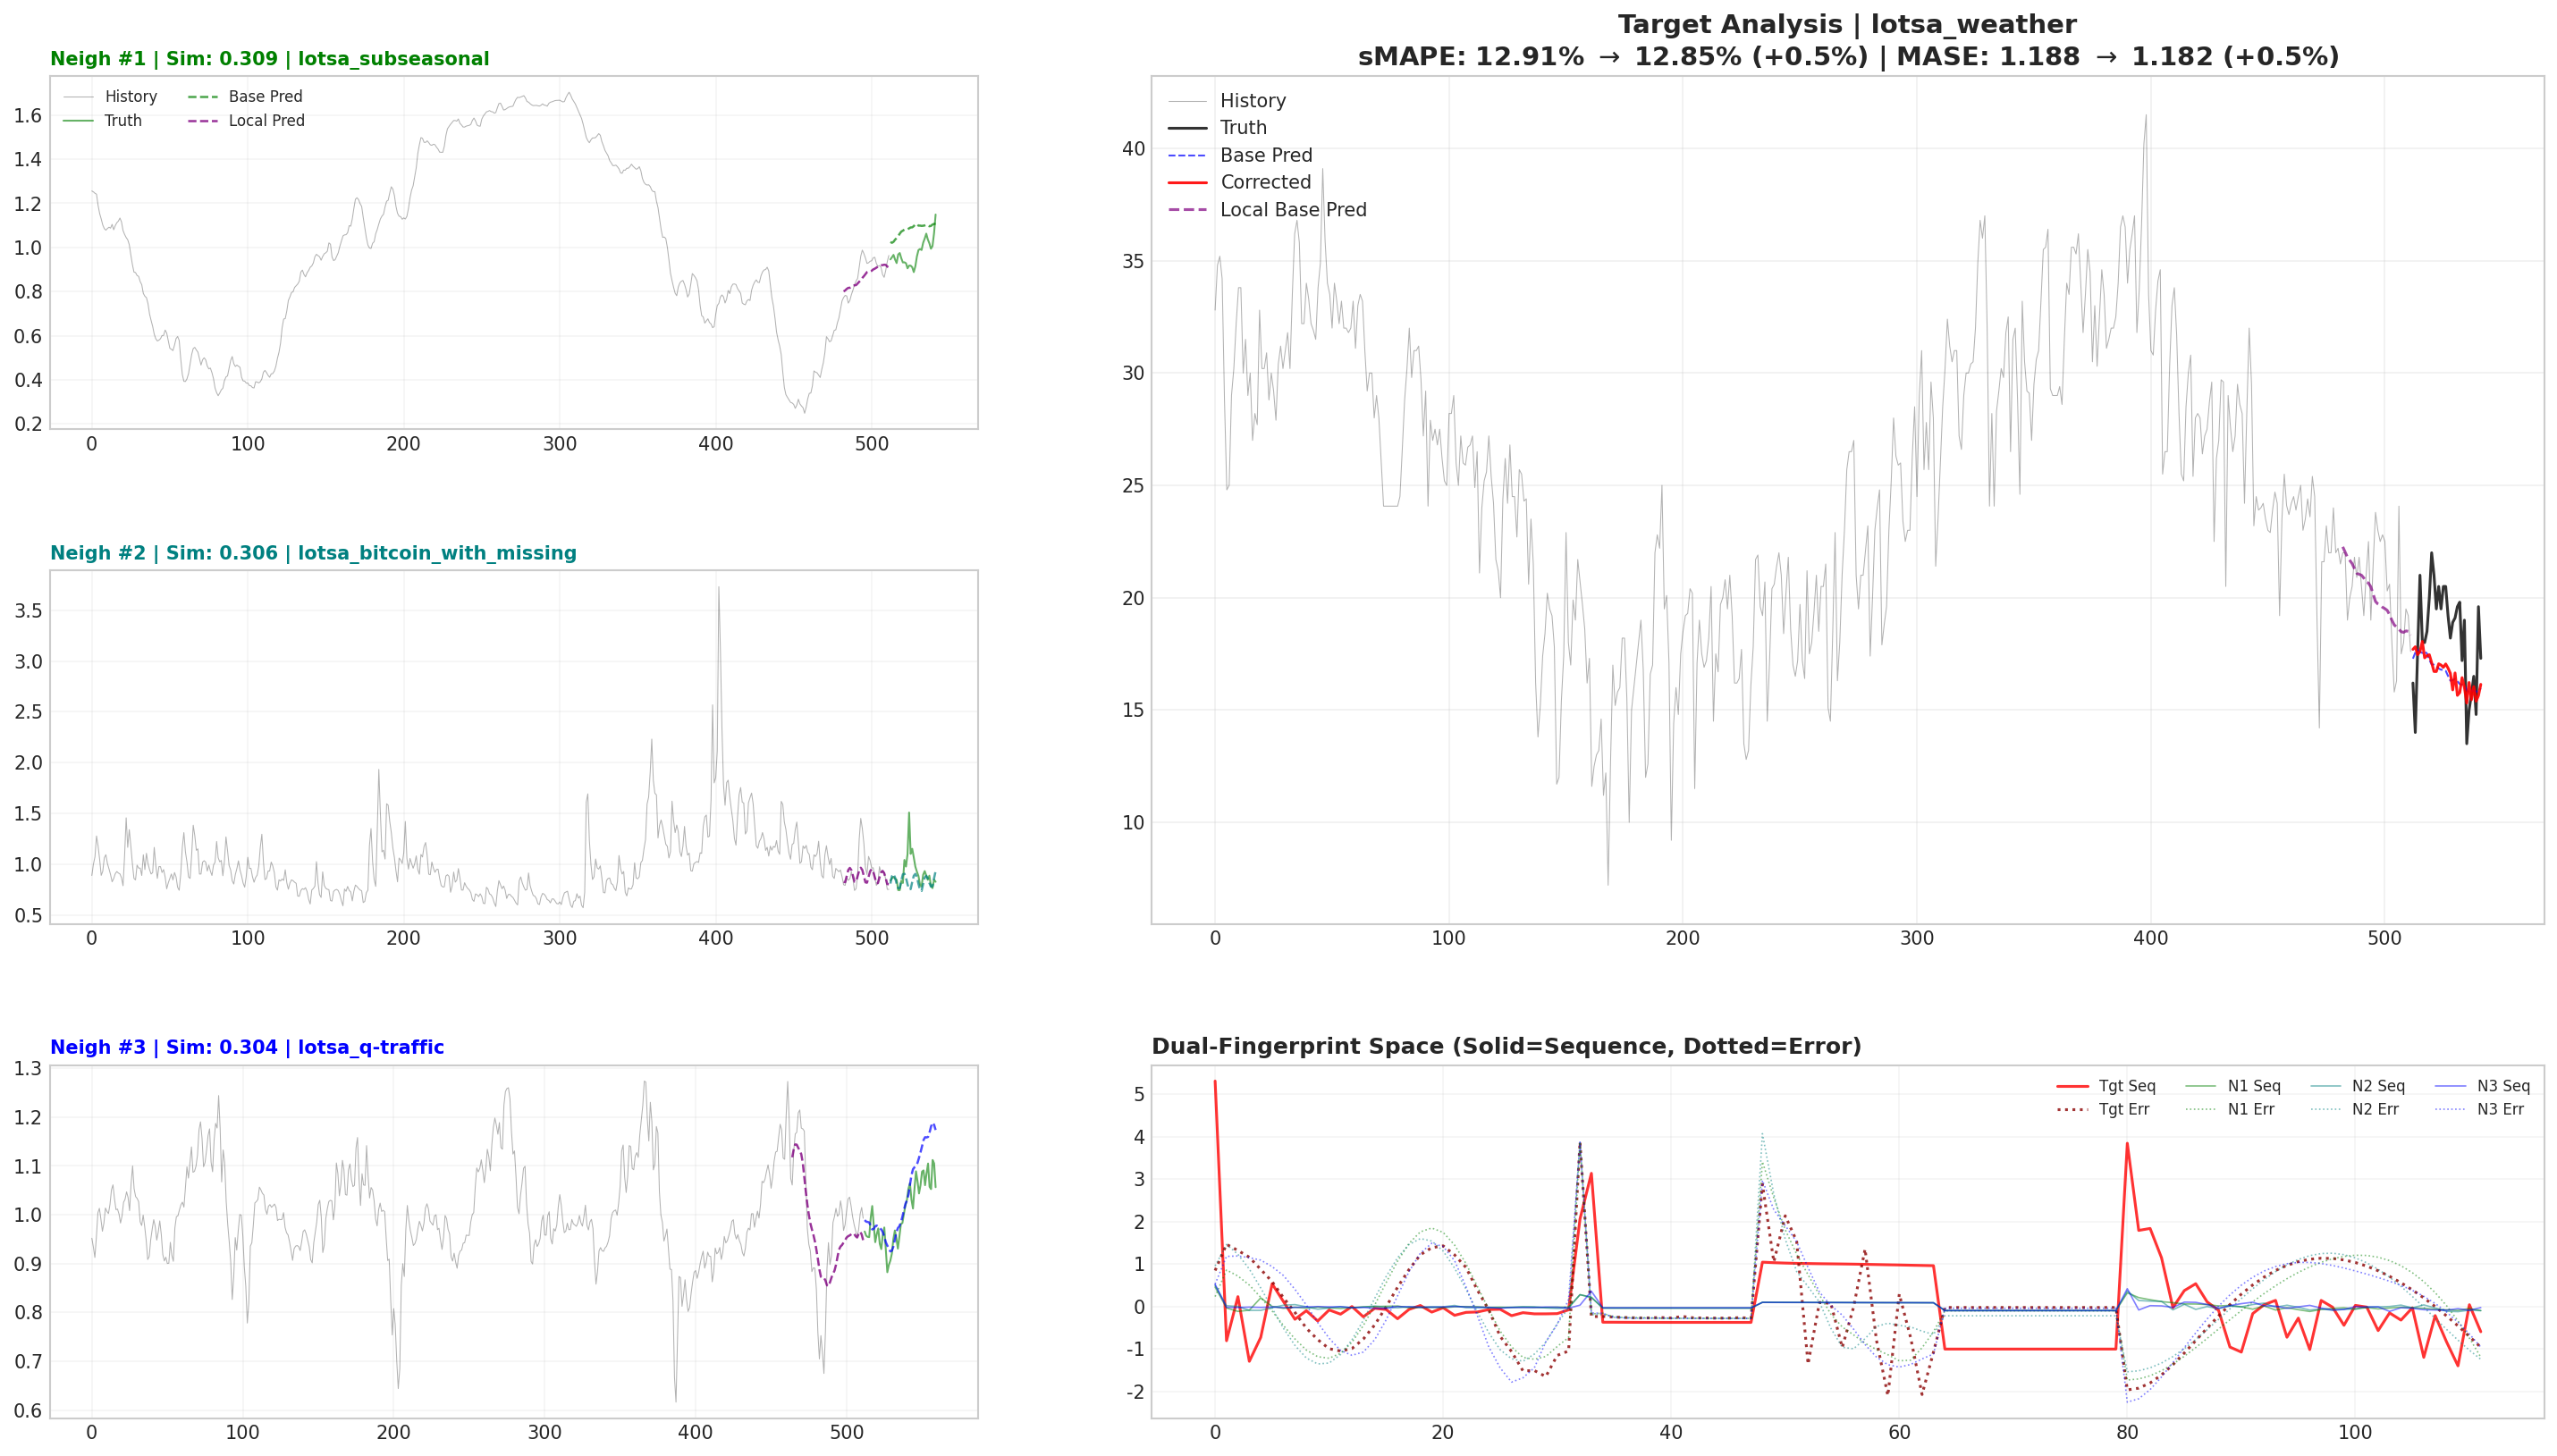

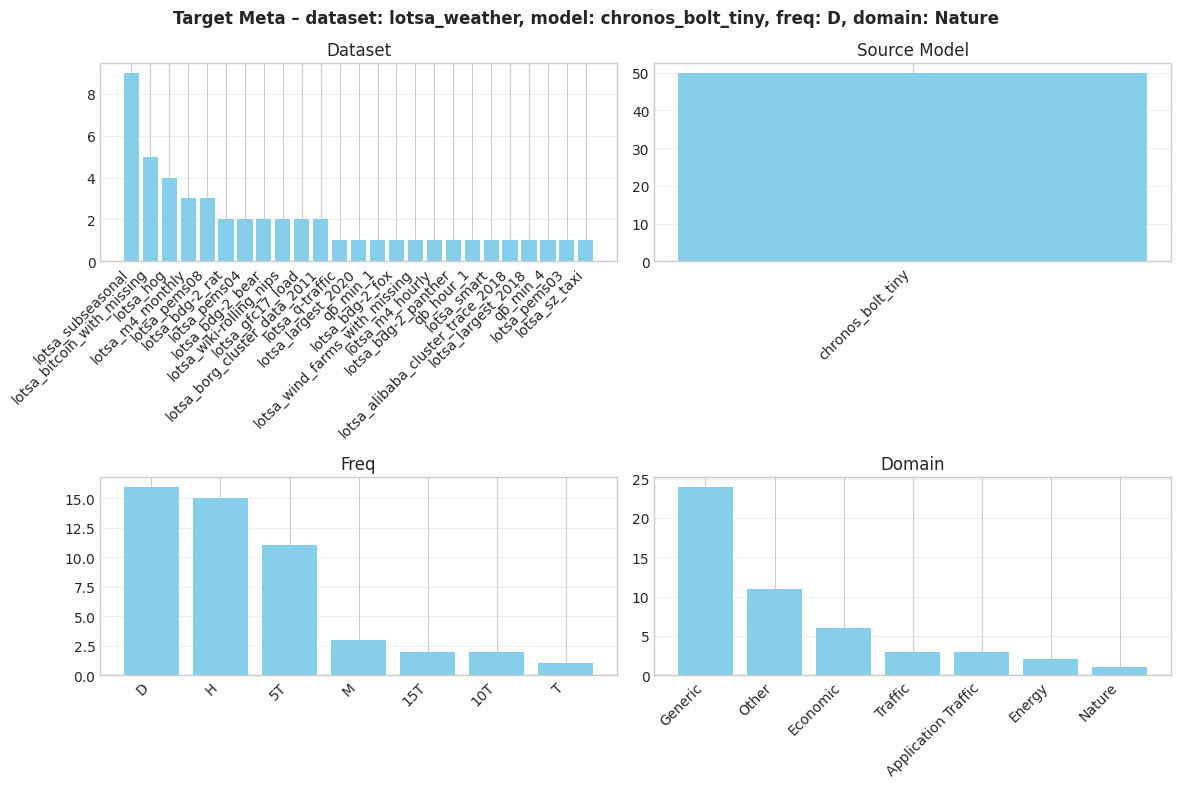

In [6]:
# ==========================================
# 5. 运行分析 (随机抽取)
# ==========================================
import random

target_model_name = "moirai_small" # 或者 "kairos_10m"chronos_bolt_tiny moirai_small

use_test = len(trainer.test_samples_dict) > 0
if use_test and target_model_name in trainer.test_samples_dict:
    samples = trainer.test_samples_dict[target_model_name]
    idx = random.randint(0, len(samples)-1)
    print(f"🎲 模式: 指定模型测试集 ({target_model_name})")
    analyze_sample(idx, use_test_set=True, specific_model=target_model_name)
elif len(trainer.train_samples) > 0:
    idx = random.randint(0, len(trainer.train_samples)-1)
    print("🎲 模式: 随机抽取训练集 (因为未找到测试集或指定模型)")
    analyze_sample(idx, use_test_set=False)
else:
    print("⚠️ 没有任何数据可供分析！")

🎲 模式: 随机抽取训练集 (因为未找到测试集或指定模型)
🔍 当前 Alpha: 0.00
Dual-Fingerprint Analysis (Alpha=0.00 | Engine=True) | Arch: dual_source_fusion
样本: qb_min_4
Metrics: sMAPE 14.09%->15.24% | MASE 1.215->1.327


C:\Users\WT\AppData\Local\Temp\ipykernel_53224\2096350746.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


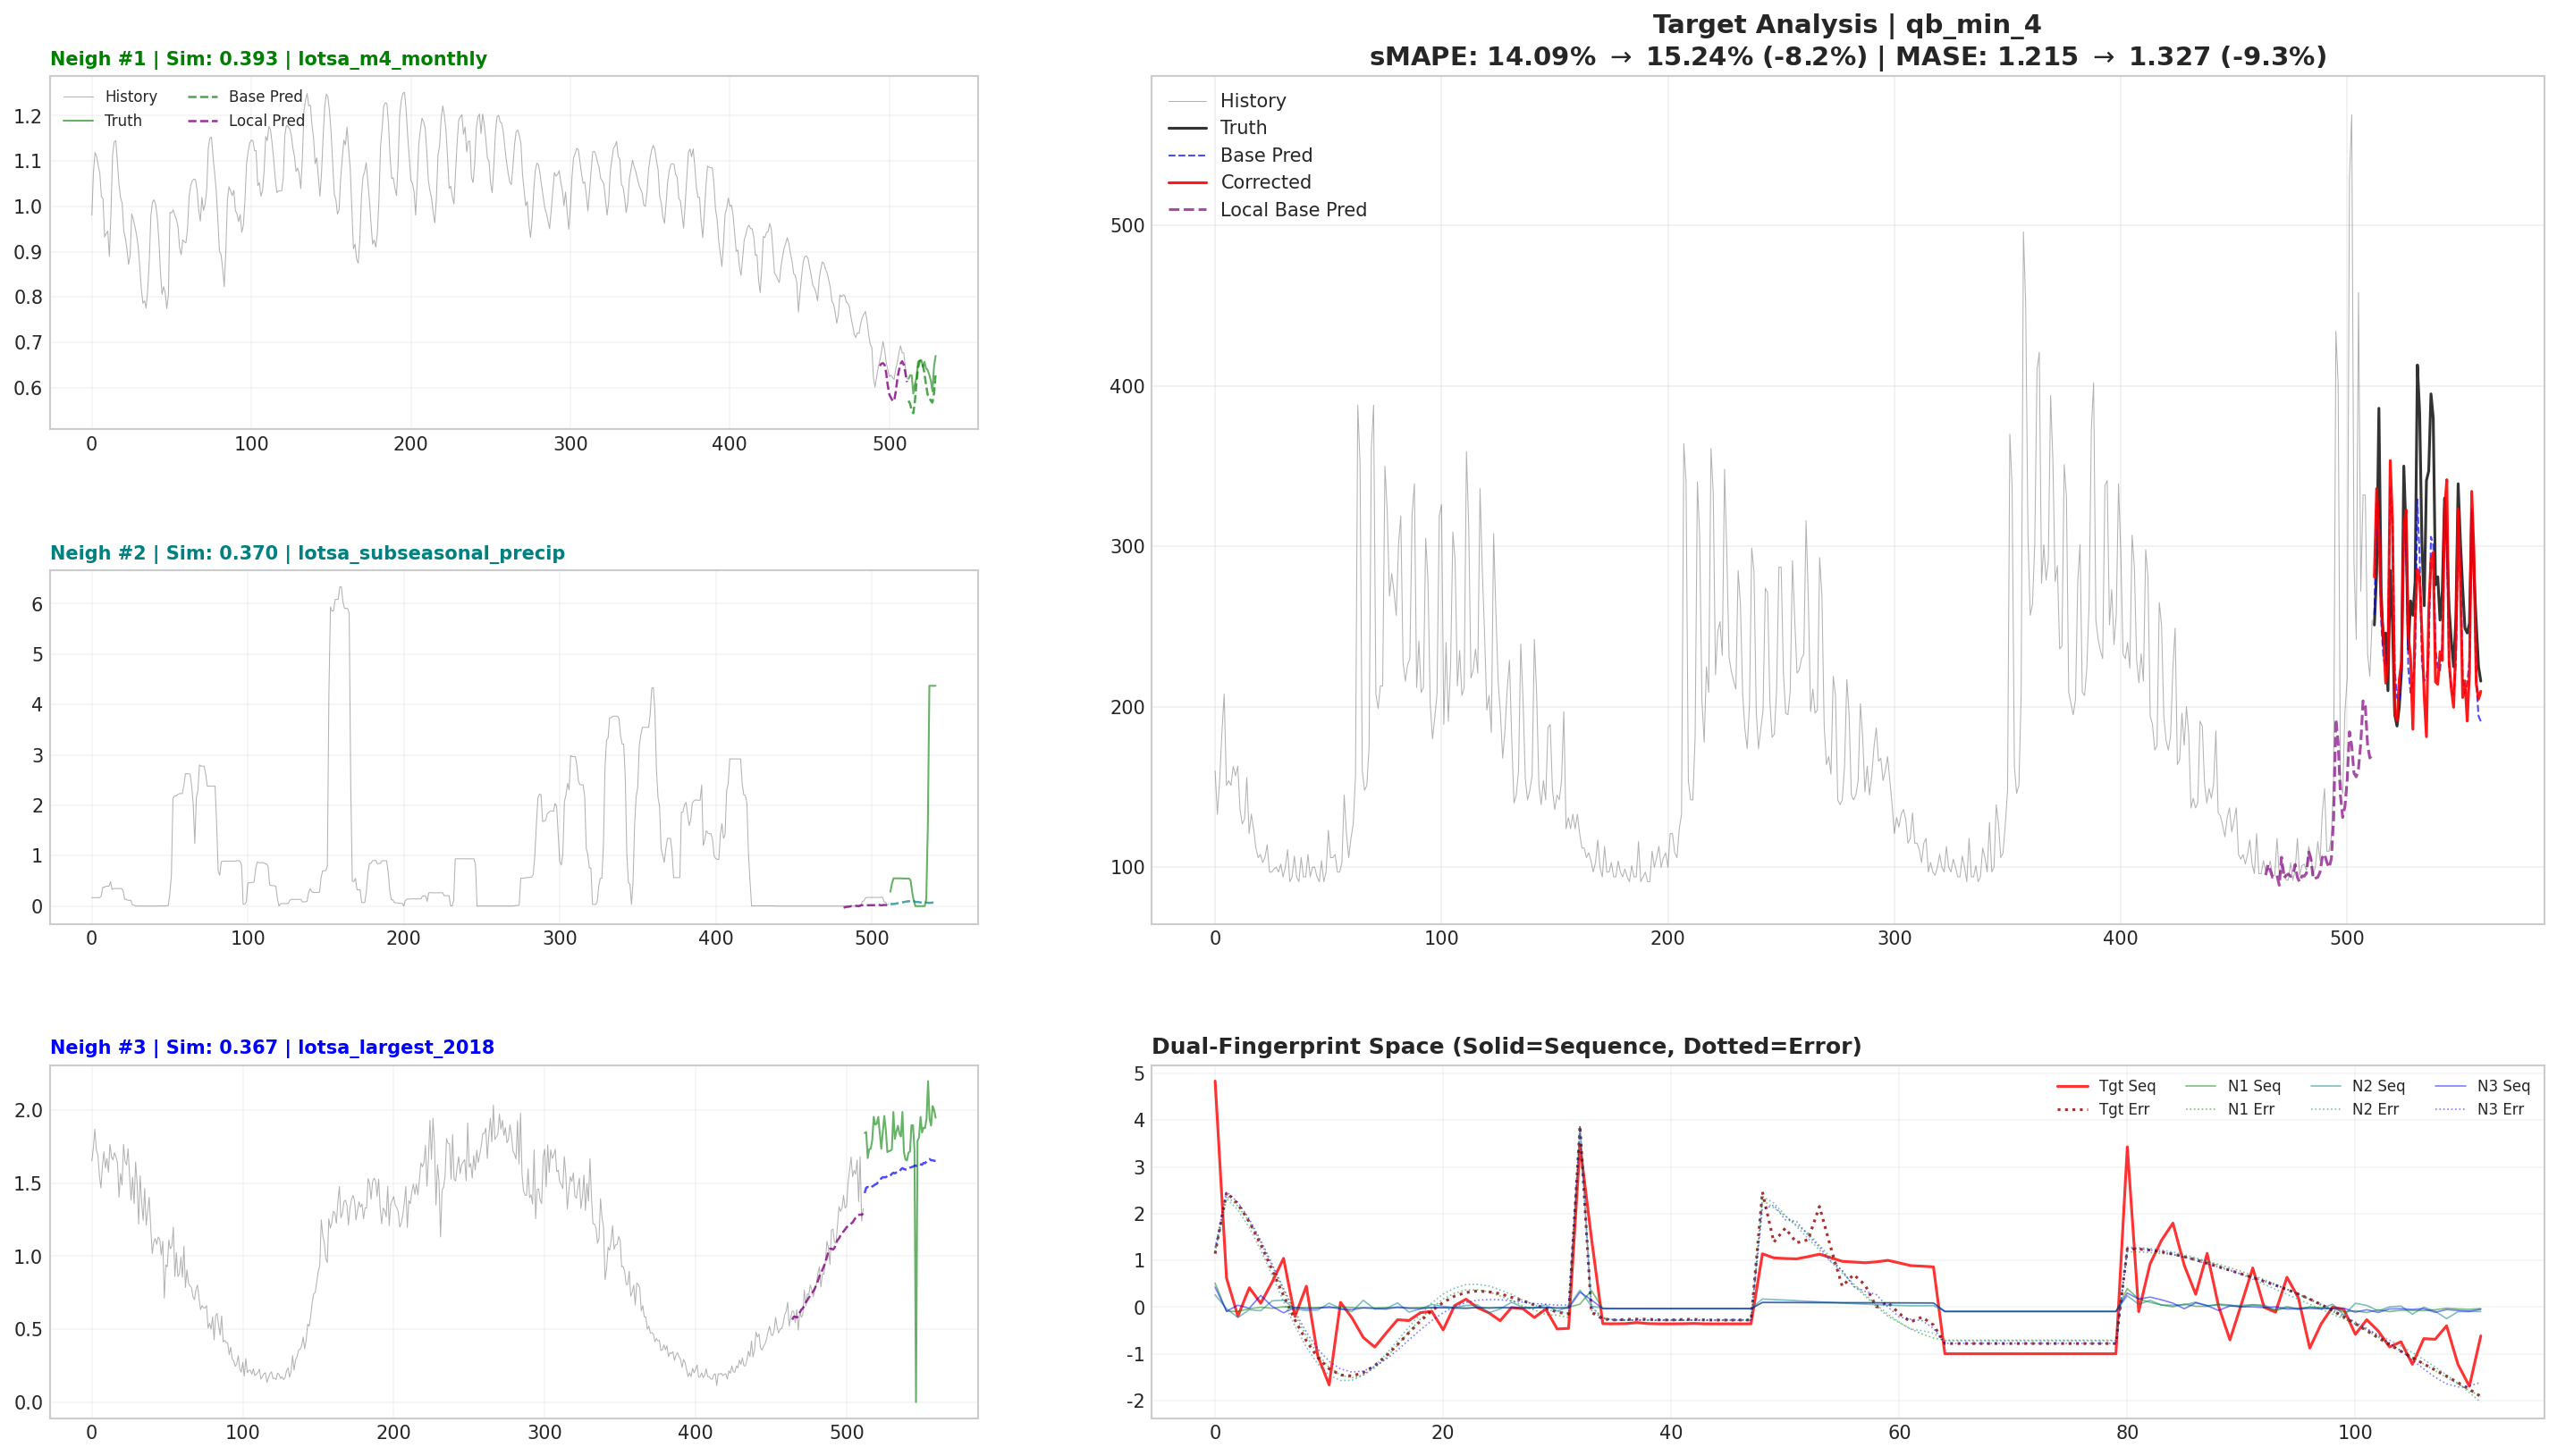

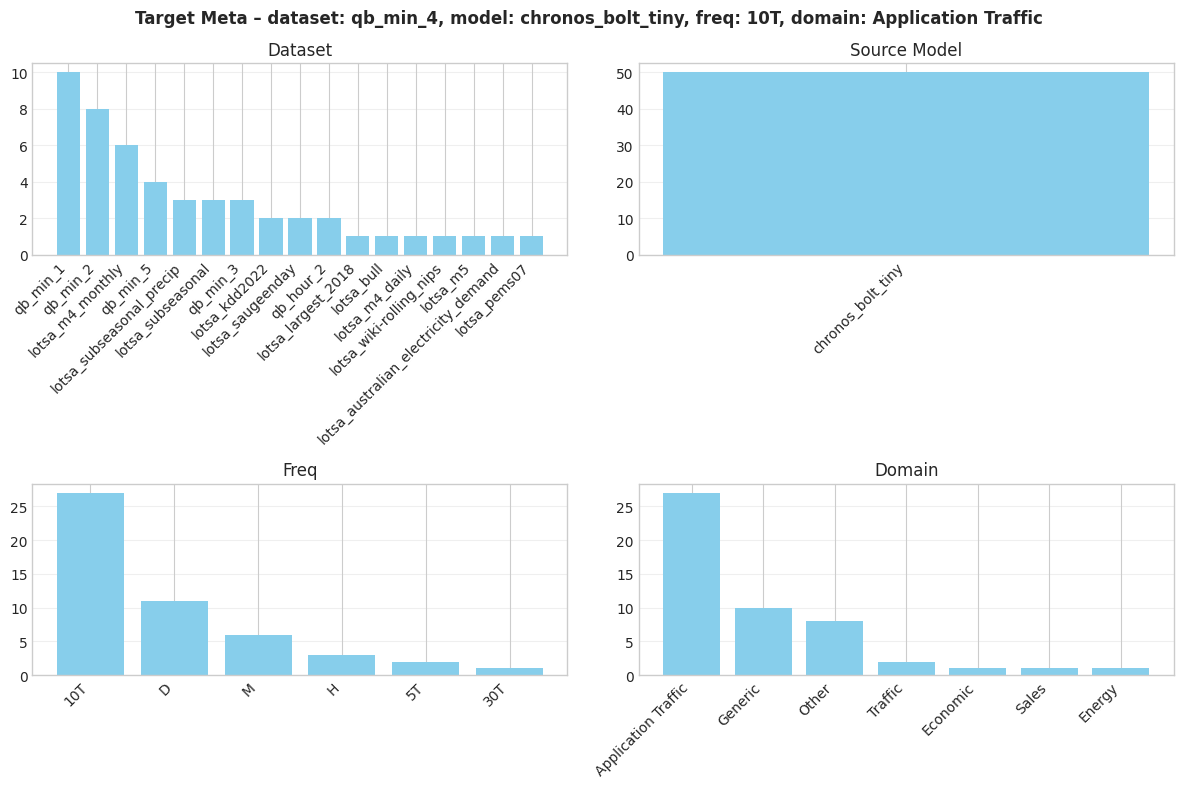

🎲 模式: 随机抽取训练集 (因为未找到测试集或指定模型)
🔍 当前 Alpha: 1.00
Dual-Fingerprint Analysis (Alpha=1.00 | Engine=True) | Arch: dual_source_fusion
样本: qb_min_4
Metrics: sMAPE 14.09%->15.31% | MASE 1.215->1.333


C:\Users\WT\AppData\Local\Temp\ipykernel_53224\2096350746.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


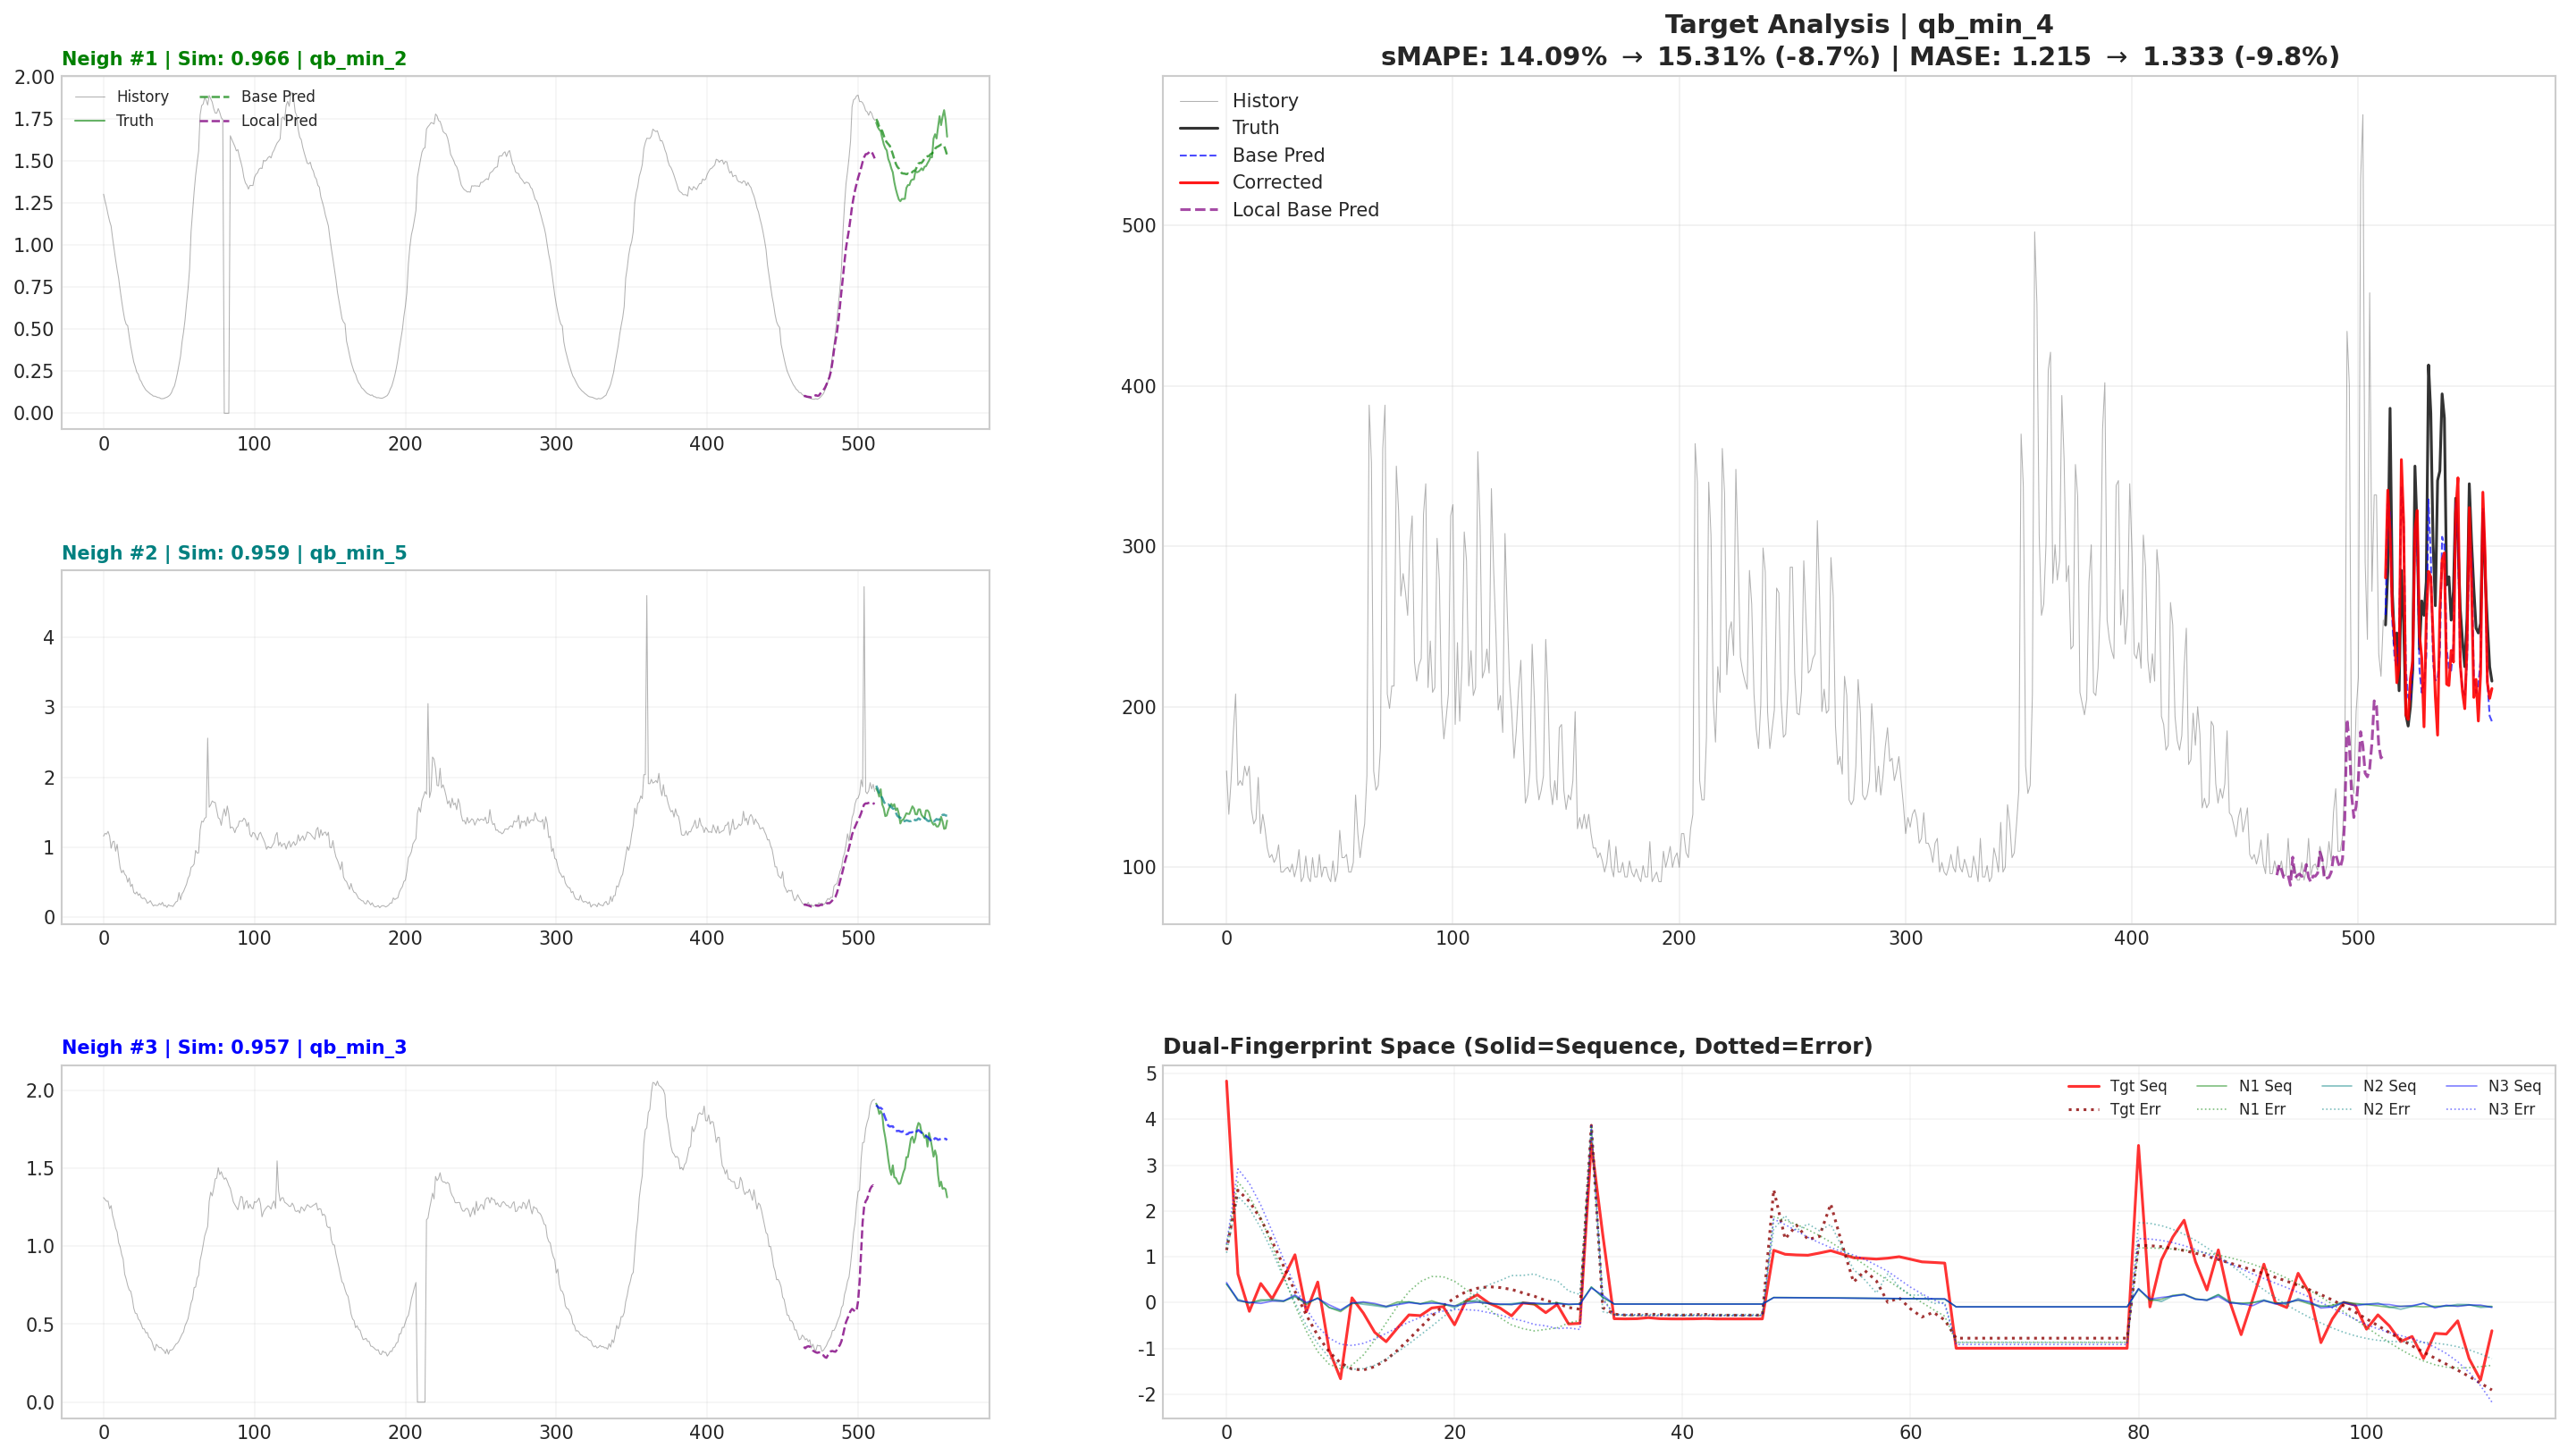

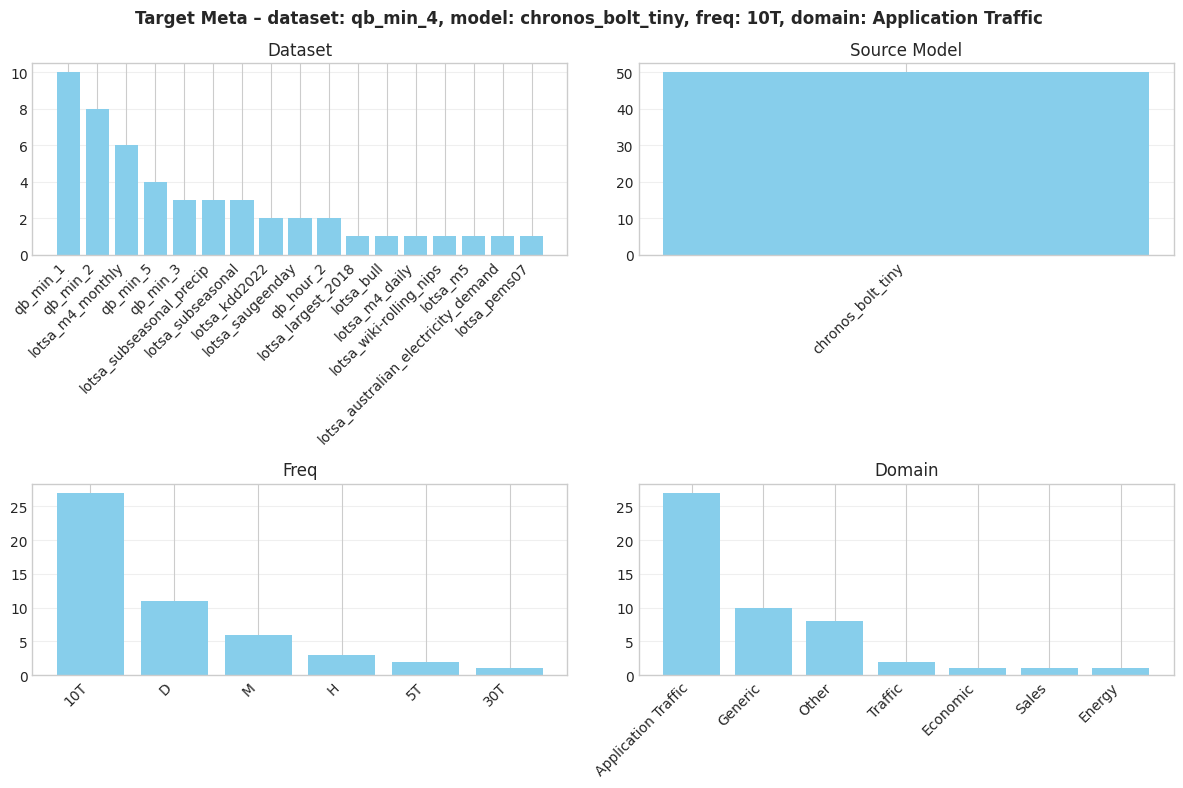

In [7]:
# ==========================================
# 5. 运行分析 (随机抽取)
# ==========================================
import random

target_model_name = "moirai_small" # 或者 "kairos_10m"chronos_bolt_tiny moirai_small

use_test = False
if use_test and target_model_name in trainer.test_samples_dict:
    idx = random.randint(0, len(trainer.train_samples)-1)
else:
    idx = random.randint(0, len(trainer.train_samples)-1)
for alpha in [0.0,1.0]:
    if use_test and target_model_name in trainer.test_samples_dict:
        samples = trainer.test_samples_dict[target_model_name]
        
        print(f"🎲 模式: 指定模型测试集 ({target_model_name})")
        print(f"🔍 当前 Alpha: {alpha:.2f}")
        analyze_sample(idx, use_test_set=True, specific_model=target_model_name,alpha=alpha)
    elif len(trainer.train_samples) > 0:
        
        print("🎲 模式: 随机抽取训练集 (因为未找到测试集或指定模型)")
        print(f"🔍 当前 Alpha: {alpha:.2f}")
        analyze_sample(idx, use_test_set=False,alpha=alpha)
    else:
        print("⚠️ 没有任何数据可供分析！")

In [8]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm

def run_global_error_distribution_analysis(trainer, model, split='test', num_bins=20):
    """
    在整个数据集上跑一遍推断，记录 Base Error, Corrected Error, Local Error，
    并绘制上下对齐的冰山柱状图，计算三向相关性。
    """
    # ==========================================
    # 1. 自动环境补齐与安全检查
    # ==========================================
    if not hasattr(trainer, 'build_loaders'):
        raise RuntimeError("❌ 请先确保 trainer.py 中已经添加了 build_loaders() 方法！")
        
    if getattr(trainer, 'val_loaders', None) is None or getattr(trainer, 'train_loader', None) is None:
        print("🛠️ 检测到 Loader 未实例化，正在通过 trainer 自动构建全量数据加载器...")
        trainer.build_loaders()
        
    model.eval()
    base_errs, corr_errs, local_errs = [], [], []
    
    if split == 'test':
        loaders = list(trainer.val_loaders.values())
        print(f"🚀 开始评估 Test Set (共 {len(loaders)} 个子集)...")
    else:
        loaders = [trainer.train_loader]
        print(f"🚀 开始评估 Train Set...")
        
    # ==========================================
    # 2. 批量高效推理 
    # ==========================================
    with torch.no_grad():
        for loader in loaders:
            for batch in tqdm(loader, desc=f"Inferencing {split}"):
                # --- 数据设备挂载 ---
                t_hist = batch['history'].to(trainer.device).squeeze(1).float()
                t_emb = batch['sample_embedding'].to(trainer.device).squeeze(1).float()
                c_embs = batch['retrieved_context'].to(trainer.device).float()
                c_res = batch['retrieved_residual'].to(trainer.device).float()
                target_res_scaled = batch['target_residual'].to(trainer.device).squeeze(1).float()
                truth = batch['truth'].to(trainer.device).squeeze(1).float()
                scale = batch['scale'].to(trainer.device).view(-1, 1).float()
                
                t_err_emb = batch.get('sample_err_embedding')
                c_err_embs = batch.get('retrieved_err_context')
                if t_err_emb is not None: t_err_emb = t_err_emb.to(trainer.device).squeeze(1).float()
                if c_err_embs is not None: c_err_embs = c_err_embs.to(trainer.device).float()
                
                target_local_res = batch.get('local_residual')
                if target_local_res is not None: 
                    target_local_res = target_local_res.to(trainer.device).float()
                
                valid_lens = trainer._get_valid_lens_from_padding(target_res_scaled)
                target_res_raw = target_res_scaled * scale
                base_pred = truth - target_res_raw
                
                # 定义批量 sMAPE 计算辅助函数
                def calc_smape_batch(pred, target, mask):
                    denom = torch.abs(pred) + torch.abs(target)
                    valid_mask = (denom > 1e-5) & mask
                    num = (200 * torch.abs(pred - target) / denom).masked_fill(~valid_mask, 0.0)
                    return num.sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1e-8)

                B, L = base_pred.shape
                mask = torch.arange(L, device=trainer.device).expand(B, L) < valid_lens.unsqueeze(1)
                
                # --- A. 计算 Base Error ---
                base_smape = calc_smape_batch(base_pred, truth, mask)
                
                # --- B. 计算 Corrected Error ---
                kwargs = {}
                # 动态提取振动特征注入模型
                if hasattr(model, 'vibe_proj'):
                    recent_hist = t_hist[:, -24:] if t_hist.shape[1] >= 24 else t_hist
                    # 防御：序列长度足够才计算，否则赋默认极小值
                    if recent_hist.shape[1] > 1:
                        hist_vol = torch.std(recent_hist, dim=1, keepdim=True) + 1e-5
                        hist_mad = torch.mean(torch.abs(recent_hist[:, 1:] - recent_hist[:, :-1]), dim=1, keepdim=True) + 1e-5
                    else:
                        hist_vol = torch.zeros((B, 1), device=trainer.device) + 1e-5
                        hist_mad = torch.zeros((B, 1), device=trainer.device) + 1e-5
                    kwargs['vibe_features'] = torch.cat([hist_vol, hist_mad], dim=1).float()
                    
                pred_norm, info = model(
                    t_emb, c_embs, c_res, t_hist, target_res_scaled,
                    t_err_emb=t_err_emb, c_err_embs=c_err_embs,
                    target_local_res=target_local_res,
                    **kwargs
                )
                pred_out = info['pred_res_normalized'] if 'pred_res_normalized' in info else pred_norm
                
                pred_corr_raw = pred_out * scale
                L_min = min(pred_corr_raw.shape[1], base_pred.shape[1])
                final_pred = base_pred[:, :L_min] + pred_corr_raw[:, :L_min]
                
                corr_smape = calc_smape_batch(final_pred, truth[:, :L_min], mask[:, :L_min])
                
                # --- C. 计算 Local Residual Error ---
                local_smape = torch.zeros(B, device=trainer.device)
                if target_local_res is not None:
                    local_res_raw = target_local_res * scale
                    L_total = local_res_raw.shape[1]
                    
                    # 提取左侧对齐过 padding 的真实历史数据段
                    local_truth_raw = t_hist * scale 
                    # 保护：防止 history 长度小于 L_total
                    if local_truth_raw.shape[1] < L_total:
                        pad_len = L_total - local_truth_raw.shape[1]
                        local_truth_raw = torch.nn.functional.pad(local_truth_raw, (pad_len, 0))
                    else:
                        local_truth_raw = local_truth_raw[:, -L_total:]
                        
                    local_base_pred_raw = local_truth_raw - local_res_raw
                    
                    # 🌟 修复：生成只激活右侧真实数据长度的 Mask，避免左侧 padding 0 稀释误差
                    idx_matrix = torch.arange(L_total, device=trainer.device).unsqueeze(0).expand(B, L_total)
                    start_indices = L_total - valid_lens.unsqueeze(1)
                    local_mask = idx_matrix >= start_indices
                    
                    local_smape = calc_smape_batch(local_base_pred_raw, local_truth_raw, local_mask)

                # 🌟 [究极防御] 强制展平为标量列表，彻底杜绝任何 Array/Tensor 维度污染 DataFrame
                base_errs.extend(base_smape.view(-1).cpu().tolist())
                corr_errs.extend(corr_smape.view(-1).cpu().tolist())
                local_errs.extend(local_smape.view(-1).cpu().tolist())

    # ==========================================
    # 3. 整理为 DataFrame
    # ==========================================
    df = pd.DataFrame({'Base_Error': base_errs, 'Corrected_Error': corr_errs, 'Local_Error': local_errs}).dropna()
    df['Gain'] = df['Base_Error'] - df['Corrected_Error']
    
    # ==========================================
    # 4. 计算并打印三向相关性 (带零方差拦截)
    # ==========================================
    print(f"\n{'='*40}\n📊 {split.upper()} SET 误差相关性分析\n{'='*40}")
    
    if df['Base_Error'].nunique() > 1 and df['Corrected_Error'].nunique() > 1:
        p_corr_1, _ = pearsonr(df['Base_Error'], df['Corrected_Error'])
        s_corr_1, _ = spearmanr(df['Base_Error'], df['Corrected_Error'])
        print(f"[1] Base vs Corrected:\n    Pearson:  {p_corr_1:+.4f}\n    Spearman: {s_corr_1:+.4f}")
    else:
        s_corr_1 = 0.0
        print("[1] Base vs Corrected: 无法计算 (数据方差为0)")
    
    # 拦截 Local Error 全为 0 的异常情况，防止 SciPy 崩溃
    if df['Local_Error'].nunique() > 1 and df['Base_Error'].nunique() > 1:
        p_corr_2, _ = pearsonr(df['Local_Error'], df['Base_Error'])
        s_corr_2, _ = spearmanr(df['Local_Error'], df['Base_Error'])
        print(f"\n[2] Local vs Base:\n    Pearson:  {p_corr_2:+.4f}\n    Spearman: {s_corr_2:+.4f} (预测未来困难度的能力)")
        
        p_corr_3, _ = pearsonr(df['Local_Error'], df['Corrected_Error'])
        s_corr_3, _ = spearmanr(df['Local_Error'], df['Corrected_Error'])
        print(f"\n[3] Local vs Corrected:\n    Pearson:  {p_corr_3:+.4f}\n    Spearman: {s_corr_3:+.4f}")
    else:
        s_corr_2, s_corr_3 = 0.0, 0.0
        print("\n[2] & [3] Local 误差无显著方差 (常数序列)，跳过 Local 相关性计算。")
    print(f"{'='*40}\n")
    
    # ==========================================
    # 5. 区间划分与冰山图绘制
    # ==========================================
    # 按 Base_Error 划分等频难度区间
    df['Bin_Q'] = pd.qcut(df['Base_Error'], q=num_bins, labels=False, duplicates='drop')
    grouped = df.groupby('Bin_Q').agg({'Base_Error': 'mean', 'Gain': 'mean'}).reset_index()
    
    x = np.arange(len(grouped))
    width = 0.6
    fig, ax = plt.subplots(figsize=(14, 8), dpi=120)
    
    # 绘制上方天蓝色柱子：表示基础误差 (Base Error)
    bars_base = ax.bar(x, grouped['Base_Error'], width, color='skyblue', edgecolor='black', alpha=0.8, label='Base Error')
    
    # 绘制下方彩色柱子：表示纯修正收益 (Gain)。正增益画在 x轴下方呈绿色，负增益呈红色。
    colors = ['#2ca02c' if g > 0 else '#d62728' for g in grouped['Gain']]
    bars_gain = ax.bar(x, -grouped['Gain'], width, color=colors, edgecolor='black', alpha=0.8, label='Gain (Green: Improved)')
    
    ax.axhline(0, color='black', linewidth=1.5)
    ax.set_title(f"Error Distribution & Correction Gain across {num_bins} Difficulty Bins ({split.upper()} Set)", fontsize=15, pad=20)
    ax.set_xlabel("Difficulty Bins (Ranked by Base Error, Left=Easy, Right=Hard)", fontsize=12)
    ax.set_ylabel("Error Metric (sMAPE %)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Bin {i+1}" for i in x], rotation=45)
    
    # 将负数刻度转正，保证视觉直观
    ticks = ax.get_yticks()
    ax.set_yticklabels([f"{abs(tick):.1f}" for tick in ticks])
    
    # 柱顶数值标注
    for bar in bars_base:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), 
                    textcoords="offset points", ha='center', va='bottom', fontsize=9, color='blue')
                    
    for bar, gain in zip(bars_gain, grouped['Gain']):
        height = bar.get_height()
        va = 'top' if height < 0 else 'bottom'
        offset = -3 if height < 0 else 3
        ax.annotate(f"{gain:+.1f}", xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, offset), 
                    textcoords="offset points", ha='center', va=va, fontsize=9, fontweight='bold',
                    color='darkgreen' if gain > 0 else 'darkred')
    
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 左上角相关性文本悬浮窗
    corr_text = f"Spearman Correlations:\n• Local vs Base: {s_corr_2:+.3f}\n• Base vs Corrected: {s_corr_1:+.3f}"
    ax.text(0.02, 0.85, corr_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
            
    plt.tight_layout()
    plt.show()

# ==========================================
# 🚀 调用示例
# ==========================================
# 分析测试集
# run_global_error_distribution_analysis(trainer, trainer.model, split='test', num_bins=20)

# 分析训练集
# run_global_error_distribution_analysis(trainer, trainer.model, split='train', num_bins=20)

In [9]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm

def run_global_error_distribution_analysis(trainer, model, split='test', num_bins=20):
    if not hasattr(trainer, 'build_loaders'):
        raise RuntimeError("❌ 请先确保 trainer.py 中已经添加了 build_loaders() 方法！")
        
    if getattr(trainer, 'val_loaders', None) is None or getattr(trainer, 'train_loader', None) is None:
        trainer.build_loaders()
        
    model.eval()
    base_errs, corr_errs, local_errs = [], [], []
    loaders = list(trainer.val_loaders.values()) if split == 'test' else [trainer.train_loader]
    print(f"🚀 开始评估 {split.upper()} Set...")
        
    with torch.no_grad():
        for loader in loaders:
            for batch in tqdm(loader, desc=f"Inferencing {split}"):
                t_hist = batch['history'].to(trainer.device).float().squeeze(1)
                t_emb = batch['sample_embedding'].to(trainer.device).float().squeeze(1)
                c_embs = batch['retrieved_context'].to(trainer.device).float()
                c_res = batch['retrieved_residual'].to(trainer.device).float()
                target_res_scaled = batch['target_residual'].to(trainer.device).float().squeeze(1)
                truth = batch['truth'].to(trainer.device).float().squeeze(1)
                scale = batch['scale'].to(trainer.device).float().view(-1, 1)
                
                B = t_hist.shape[0]
                
                t_err_emb = batch.get('sample_err_embedding')
                c_err_embs = batch.get('retrieved_err_context')
                if t_err_emb is not None: t_err_emb = t_err_emb.to(trainer.device).float().squeeze(1)
                if c_err_embs is not None: c_err_embs = c_err_embs.to(trainer.device).float()
                
                target_local_res = batch.get('local_residual')
                if target_local_res is not None: 
                    target_local_res = target_local_res.to(trainer.device).float()
                    if target_local_res.dim() == 3:
                        target_local_res = target_local_res.squeeze(1)
                    target_local_res = target_local_res.view(B, -1)
                
                valid_lens = trainer._get_valid_lens_from_padding(target_res_scaled)
                target_res_raw = target_res_scaled * scale
                base_pred = truth - target_res_raw
                L = base_pred.shape[1]
                
                def calc_smape_batch(pred, target, mask):
                    denom = torch.abs(pred) + torch.abs(target)
                    valid_mask = (denom > 1e-5) & mask
                    num = (200 * torch.abs(pred - target) / denom).masked_fill(~valid_mask, 0.0)
                    return num.sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1e-8)

                mask = torch.arange(L, device=trainer.device).expand(B, L) < valid_lens.unsqueeze(1)
                base_smape = calc_smape_batch(base_pred, truth, mask)
                
                kwargs = {}
                if hasattr(model, 'vibe_proj'):
                    recent_hist = t_hist[:, -24:] if t_hist.shape[1] >= 24 else t_hist
                    if recent_hist.shape[1] > 1:
                        kwargs['vibe_features'] = torch.cat([
                            torch.std(recent_hist, dim=1, keepdim=True) + 1e-5,
                            torch.mean(torch.abs(recent_hist[:, 1:] - recent_hist[:, :-1]), dim=1, keepdim=True) + 1e-5
                        ], dim=1).float()
                    
                pred_norm, info = model(
                    t_emb, c_embs, c_res, t_hist, target_res_scaled,
                    t_err_emb=t_err_emb, c_err_embs=c_err_embs, target_local_res=target_local_res, **kwargs
                )
                pred_out = info.get('pred_res_normalized', pred_norm)
                
                pred_corr_raw = pred_out * scale
                L_min = min(pred_corr_raw.shape[1], base_pred.shape[1])
                corr_smape = calc_smape_batch(base_pred[:, :L_min] + pred_corr_raw[:, :L_min], truth[:, :L_min], mask[:, :L_min])
                
                local_smape = torch.zeros(B, device=trainer.device)
                if target_local_res is not None:
                    local_res_raw = target_local_res * scale
                    L_total = local_res_raw.shape[1]
                    local_truth_raw = t_hist * scale 
                    
                    if local_truth_raw.shape[1] < L_total:
                        local_truth_raw = torch.nn.functional.pad(local_truth_raw, (L_total - local_truth_raw.shape[1], 0))
                    else:
                        local_truth_raw = local_truth_raw[:, -L_total:]
                        
                    local_base_pred_raw = local_truth_raw - local_res_raw 
                    local_mask = (torch.arange(L_total, device=trainer.device).unsqueeze(0).expand(B, L_total) >= (L_total - valid_lens.unsqueeze(1)))
                    local_smape = calc_smape_batch(local_base_pred_raw, local_truth_raw, local_mask)

                base_errs.extend(base_smape.view(-1).cpu().tolist()[:B])
                corr_errs.extend(corr_smape.view(-1).cpu().tolist()[:B])
                local_errs.extend(local_smape.view(-1).cpu().tolist()[:B])

    # ==========================================
    # 数据整理与指标计算
    # ==========================================
    min_len = min(len(base_errs), len(corr_errs), len(local_errs))
    df = pd.DataFrame({
        'Base_Error': base_errs[:min_len], 
        'Corrected_Error': corr_errs[:min_len], 
        'Local_Error': local_errs[:min_len]
    }).dropna()
    
    df['Gain'] = df['Base_Error'] - df['Corrected_Error']
    # 新增：计算增益率 (Gain Rate)
    df['Gain_Rate'] = df['Gain'] / (df['Base_Error'] + 1e-8) * 100 
    
    print(f"\n{'='*40}\n📊 {split.upper()} SET 误差相关性分析\n{'='*40}")
    if df['Base_Error'].nunique() > 1 and df['Corrected_Error'].nunique() > 1:
        p_corr_1, _ = pearsonr(df['Base_Error'], df['Corrected_Error'])
        s_corr_1, _ = spearmanr(df['Base_Error'], df['Corrected_Error'])
        print(f"[1] Base vs Corrected:\n    Pearson:  {p_corr_1:+.4f}\n    Spearman: {s_corr_1:+.4f}")
    else: s_corr_1 = 0.0

    if df['Local_Error'].nunique() > 1 and df['Base_Error'].nunique() > 1:
        p_corr_2, _ = pearsonr(df['Local_Error'], df['Base_Error'])
        s_corr_2, _ = spearmanr(df['Local_Error'], df['Base_Error'])
        print(f"\n[2] Local vs Base:\n    Pearson:  {p_corr_2:+.4f}\n    Spearman: {s_corr_2:+.4f} (历史预测未来的可靠性)")
        p_corr_3, _ = pearsonr(df['Local_Error'], df['Corrected_Error'])
        s_corr_3, _ = spearmanr(df['Local_Error'], df['Corrected_Error'])
        print(f"\n[3] Local vs Corrected:\n    Pearson:  {p_corr_3:+.4f}\n    Spearman: {s_corr_3:+.4f}")
    else:
        s_corr_2 = 0.0
        print("\n[2] Local Error 为常数序列，跳过相关性。")
    print(f"{'='*40}\n")
    
    # ==========================================
    # 可视化子函数 (支持任意指标排序)
    # ==========================================
    def plot_iceberg_chart(sort_col, x_label_text, title_text):
        # 1. 按照传入的列进行分位数划分
        df['Bin'] = pd.qcut(df[sort_col], q=num_bins, labels=False, duplicates='drop')
        grouped = df.groupby('Bin').agg({
            'Base_Error': 'mean', 
            'Local_Error': 'mean',
            'Gain': 'mean'
        }).reset_index()
        
        x = np.arange(len(grouped))
        w = 0.35 # 柱子宽度
        fig, ax = plt.subplots(figsize=(15, 8), dpi=120)
        
        # 2. 绘制上方双柱 (Base Error & Local Error)
        bars_base = ax.bar(x - w/2, grouped['Base_Error'], w, color='skyblue', edgecolor='black', alpha=0.9, label='Base Error')
        bars_local = ax.bar(x + w/2, grouped['Local_Error'], w, color='navajowhite', edgecolor='black', alpha=0.9, label='Local Error')
        
        # 3. 绘制下方增益柱 (Gain)
        colors = ['#2ca02c' if g > 0 else '#d62728' for g in grouped['Gain']]
        # 下方的柱子做宽一点，覆盖上方两个柱子的总宽度
        bars_gain = ax.bar(x, -grouped['Gain'], w*2, color=colors, edgecolor='black', alpha=0.8, label='Gain (Green: Improved)')
        
        # 4. 样式设置
        ax.axhline(0, color='black', linewidth=1.5)
        ax.set_title(title_text, fontsize=15, fontweight='bold', pad=20)
        ax.set_xlabel(x_label_text, fontsize=12)
        ax.set_ylabel("Error Metric (sMAPE %)", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels([f"Bin {i+1}" for i in x], rotation=45)
        
        # 将负 y 轴刻度显示为正的绝对值
        ticks = ax.get_yticks()
        ax.set_yticklabels([f"{abs(tick):.1f}" for tick in ticks])
        
        # 5. 数值标注 (防止拥挤，缩小字体并轻微旋转)
        for bar in bars_base:
            h = bar.get_height()
            ax.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8, color='dodgerblue', rotation=0)
        for bar in bars_local:
            h = bar.get_height()
            ax.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8, color='darkorange', rotation=0)
        for bar, gain in zip(bars_gain, grouped['Gain']):
            h = bar.get_height()
            ax.annotate(f"{gain:+.1f}", xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, -3 if h < 0 else 3), textcoords="offset points", ha='center', va='top' if h < 0 else 'bottom', fontsize=9, fontweight='bold', color='darkgreen' if gain > 0 else 'darkred')
        
        ax.legend(loc='upper left', fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        # 仅在第一张图左上角加上相关性分析
        if sort_col == 'Base_Error':
            corr_text = f"Spearman:\n• Local vs Base: {s_corr_2:+.3f}\n• Base vs Corrected: {s_corr_1:+.3f}"
            ax.text(0.02, 0.82, corr_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
            
        plt.tight_layout()
        plt.show()

    # ==========================================
    # 执行两轮绘图
    # ==========================================
    # 图 1：按 Base Error (预测难度) 排序
    plot_iceberg_chart(
        sort_col='Base_Error', 
        x_label_text="Difficulty Bins (Ranked by Base Error, Left=Easy, Right=Hard)",
        title_text=f"Error Distribution & Correction Gain ({split.upper()} Set) - Ranked by Base Error"
    )
    
    # 图 2：按 Gain Rate (增益率) 排序
    plot_iceberg_chart(
        sort_col='Gain_Rate', 
        x_label_text="Performance Bins (Ranked by Gain Rate, Left=Worsened/Lowest, Right=Improved/Highest)",
        title_text=f"Error Distribution & Correction Gain ({split.upper()} Set) - Ranked by Gain Rate"
    )

# ==========================================
# 🚀 运行方法
# ==========================================
# run_global_error_distribution_analysis(trainer, trainer.model, split='test', num_bins=20)

Retrieving: 100%|██████████| 7/7 [00:00<00:00,  7.23it/s]


🚀 开始评估 TEST Set...


Inferencing test: 100%|██████████| 3526/3526 [00:10<00:00, 336.15it/s]
C:\Users\WT\AppData\Local\Temp\ipykernel_53224\2378289127.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{abs(tick):.1f}" for tick in ticks])



📊 TEST SET 误差相关性分析
[1] Base vs Corrected:
    Pearson:  +0.3532
    Spearman: +0.2749

[2] Local vs Base:
    Pearson:  +0.8170
    Spearman: +0.7839 (历史预测未来的可靠性)

[3] Local vs Corrected:
    Pearson:  +0.2642
    Spearman: -0.1688



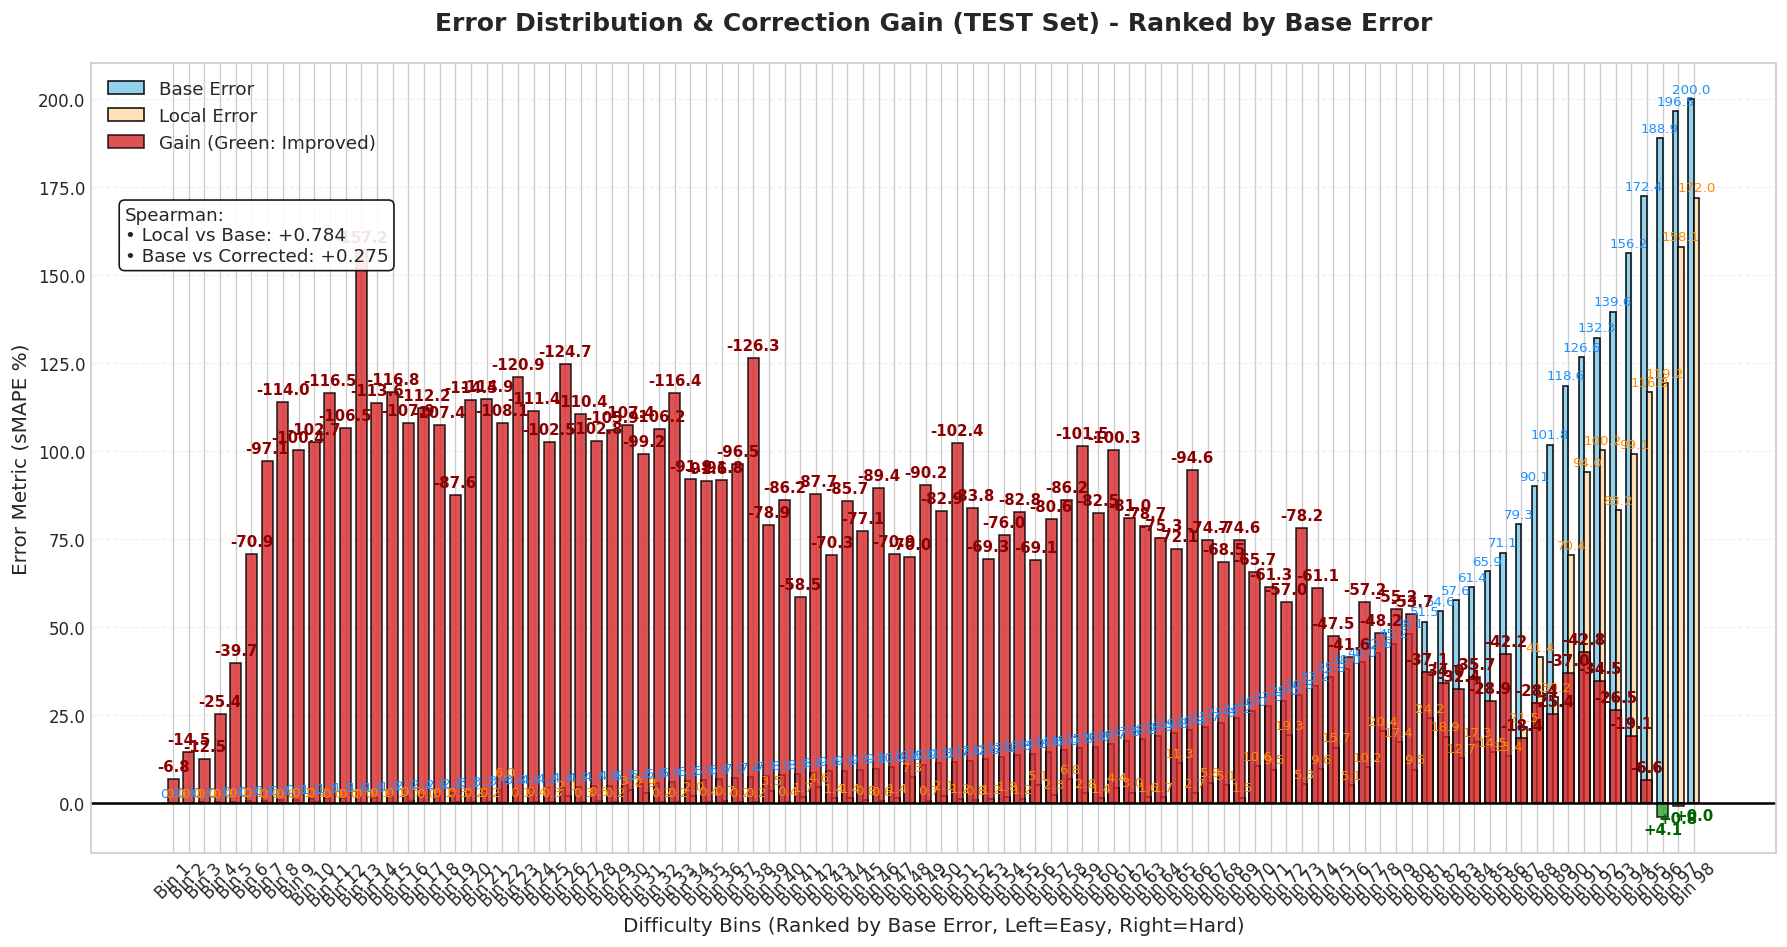

C:\Users\WT\AppData\Local\Temp\ipykernel_53224\2378289127.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{abs(tick):.1f}" for tick in ticks])


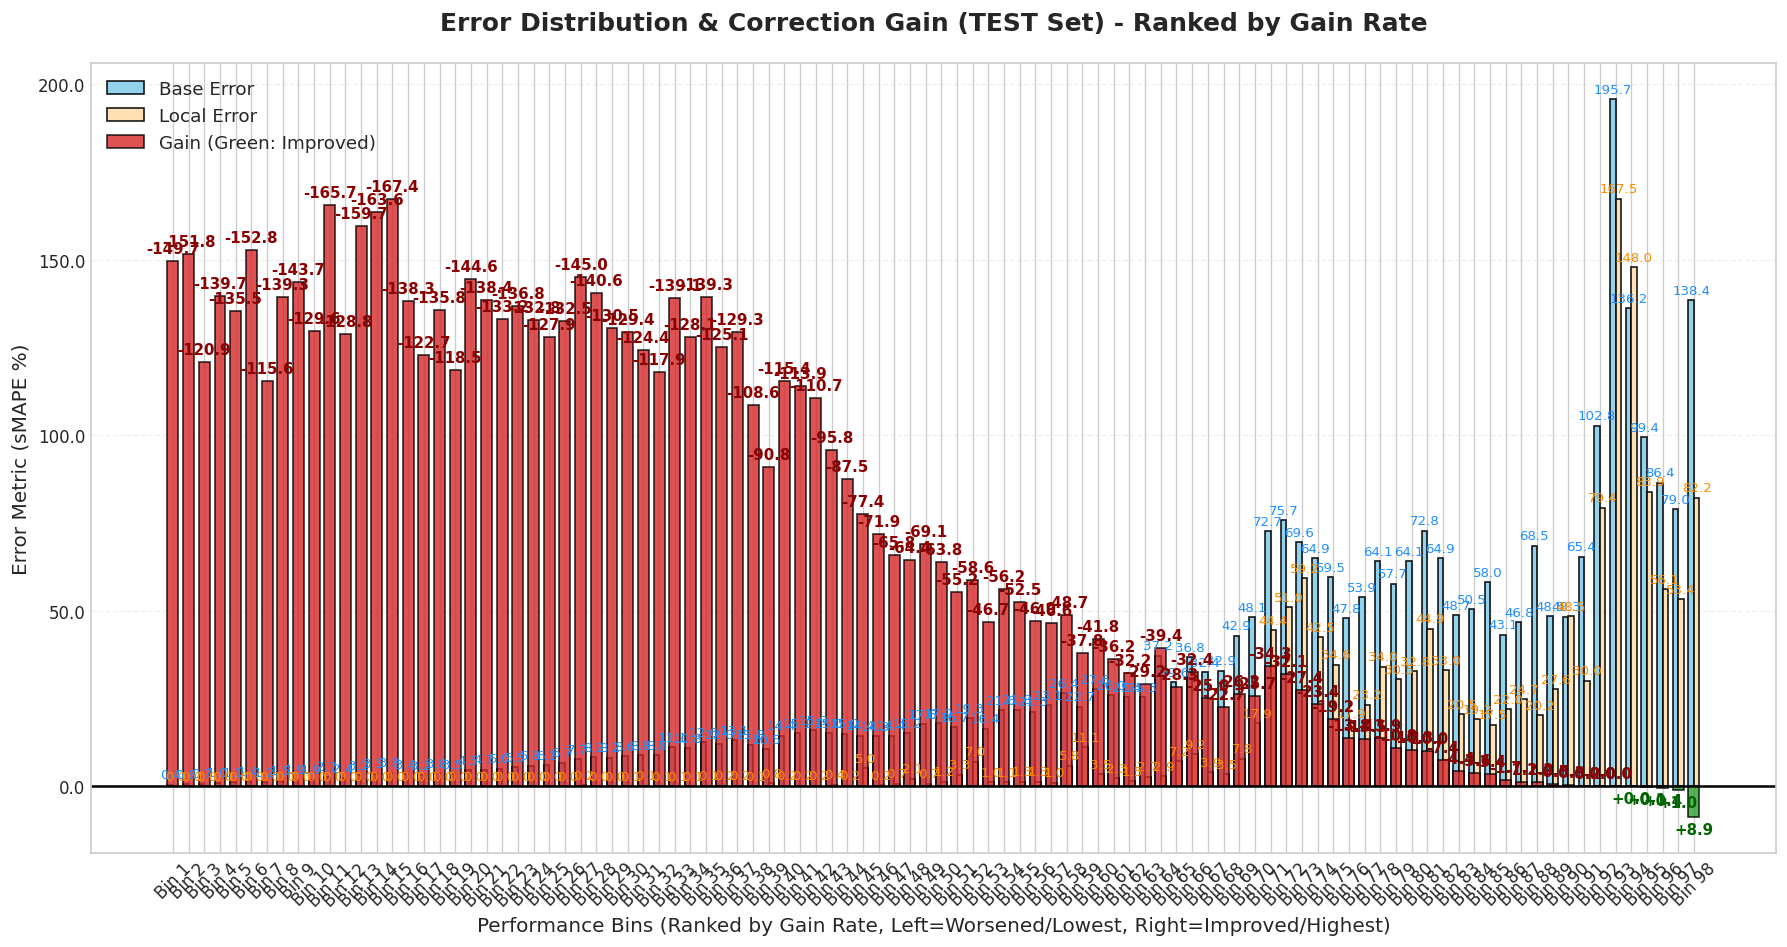

In [10]:
run_global_error_distribution_analysis(trainer, trainer.model, split='test', num_bins=100)

In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import spearmanr

def analyze_positive_gain_patterns(trainer, model, split='test'):
    """
    深度正增益样本共性挖掘：时频域多特征提取与多视图可视化
    """
    if not hasattr(trainer, 'build_loaders'):
        raise RuntimeError("❌ 请先确保 trainer.py 中已经添加了 build_loaders() 方法！")
        
    if getattr(trainer, 'val_loaders', None) is None or getattr(trainer, 'train_loader', None) is None:
        trainer.build_loaders()
        
    model.eval()
    
    # 收集容器
    data_records = {
        'Base_Error': [], 'Corr_Error': [], 'Local_Error': [], 
        'Volatility': [], 'MAD': [], 'Trend': [], 'Peak_to_Peak': [],
        'Low_Freq_Energy': [], 'High_Freq_Energy': [], 'Freq_Energy_Ratio': [],
        'Domain': [], 'Freq_Meta': []
    }
    
    loaders = list(trainer.val_loaders.values()) if split == 'test' else [trainer.train_loader]
    print(f"🚀 开始全量推理并进行时/频域特征提取 ({split.upper()} Set)...")
        
    with torch.no_grad():
        for loader in loaders:
            for batch in tqdm(loader, desc=f"Feature Extraction & Inferencing"):
                # 1. 基础张量准备
                t_hist = batch['history'].to(trainer.device).float().squeeze(1)
                t_emb = batch['sample_embedding'].to(trainer.device).float().squeeze(1)
                c_embs = batch['retrieved_context'].to(trainer.device).float()
                c_res = batch['retrieved_residual'].to(trainer.device).float()
                target_res_scaled = batch['target_residual'].to(trainer.device).float().squeeze(1)
                truth = batch['truth'].to(trainer.device).float().squeeze(1)
                scale = batch['scale'].to(trainer.device).float().view(-1, 1)
                
                B, L_hist = t_hist.shape
                
                # 2. 推理计算误差
                target_local_res = batch.get('local_residual')
                if target_local_res is not None:
                    target_local_res = target_local_res.to(trainer.device).float()
                    if target_local_res.dim() == 3: target_local_res = target_local_res.squeeze(1)
                    target_local_res = target_local_res.view(B, -1)
                
                valid_lens = trainer._get_valid_lens_from_padding(target_res_scaled)
                base_pred = truth - (target_res_scaled * scale)
                L = base_pred.shape[1]
                
                def calc_smape_batch(pred, target, mask):
                    denom = torch.abs(pred) + torch.abs(target)
                    valid_mask = (denom > 1e-5) & mask
                    num = (200 * torch.abs(pred - target) / denom).masked_fill(~valid_mask, 0.0)
                    return num.sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1e-8)

                mask = torch.arange(L, device=trainer.device).expand(B, L) < valid_lens.unsqueeze(1)
                base_smape = calc_smape_batch(base_pred, truth, mask)
                
                kwargs = {}
                # 提取历史波动特征传入模型
                if hasattr(model, 'vibe_proj') and L_hist > 1:
                    kwargs['vibe_features'] = torch.cat([
                        torch.std(t_hist[:, -24:], dim=1, keepdim=True) + 1e-5,
                        torch.mean(torch.abs(t_hist[:, -24:][:, 1:] - t_hist[:, -24:][:, :-1]), dim=1, keepdim=True) + 1e-5
                    ], dim=1).float()
                    
                t_err_emb = batch.get('sample_err_embedding')
                c_err_embs = batch.get('retrieved_err_context')
                if t_err_emb is not None: t_err_emb = t_err_emb.to(trainer.device).float().squeeze(1)
                if c_err_embs is not None: c_err_embs = c_err_embs.to(trainer.device).float()
                
                pred_out = model(t_emb, c_embs, c_res, t_hist, target_res_scaled, 
                                 t_err_emb=t_err_emb, c_err_embs=c_err_embs, target_local_res=target_local_res, **kwargs)
                pred_out = pred_out[1].get('pred_res_normalized', pred_out[0])
                
                pred_corr_raw = pred_out * scale
                L_min = min(pred_corr_raw.shape[1], base_pred.shape[1])
                corr_smape = calc_smape_batch(base_pred[:, :L_min] + pred_corr_raw[:, :L_min], truth[:, :L_min], mask[:, :L_min])
                
                local_smape = torch.zeros(B, device=trainer.device)
                if target_local_res is not None:
                    local_res_raw = target_local_res * scale
                    L_total = local_res_raw.shape[1]
                    local_truth_raw = t_hist * scale 
                    if local_truth_raw.shape[1] < L_total:
                        local_truth_raw = torch.nn.functional.pad(local_truth_raw, (L_total - local_truth_raw.shape[1], 0))
                    else:
                        local_truth_raw = local_truth_raw[:, -L_total:]
                    local_base_pred_raw = local_truth_raw - local_res_raw 
                    local_mask = (torch.arange(L_total, device=trainer.device).unsqueeze(0).expand(B, L_total) >= (L_total - valid_lens.unsqueeze(1)))
                    local_smape = calc_smape_batch(local_base_pred_raw, local_truth_raw, local_mask)

                # ==========================================
                # 3. 核心：提取多视角统计物理特征 (时域 + 频域)
                # ==========================================
                # A. 时域特征 (Time Domain)
                hist_volatility = torch.std(t_hist, dim=1) # 整体波动率
                hist_mad = torch.mean(torch.abs(t_hist[:, 1:] - t_hist[:, :-1]), dim=1) # 高频毛刺(MAD)
                hist_trend = torch.abs((t_hist[:, -1] - t_hist[:, 0])) / L_hist # 宏观趋势强度
                hist_ptp = torch.max(t_hist, dim=1)[0] - torch.min(t_hist, dim=1)[0] # 极差振幅
                
                # B. 频域特征 (Frequency Domain via FFT)
                # 使用快速傅里叶变换计算序列能量谱
                fft_mag = torch.abs(torch.fft.rfft(t_hist, dim=1)) 
                F = fft_mag.shape[1]
                split_idx = max(1, int(F * 0.2)) # 前 20% 归为低频(慢周期/趋势)，后 80% 归为高频(快振动/噪声)
                
                low_freq_energy = torch.sum(fft_mag[:, :split_idx], dim=1)
                high_freq_energy = torch.sum(fft_mag[:, split_idx:], dim=1)
                freq_ratio = high_freq_energy / (low_freq_energy + 1e-5) # 高低频能量比
                
                # C. 元信息 (Meta)
                domains = batch.get('domain', ['Unknown'] * B)
                freqs = batch.get('freq', ['Unknown'] * B)

                # ==========================================
                # 4. 录入数据容器
                # ==========================================
                data_records['Base_Error'].extend(base_smape.view(-1).cpu().tolist()[:B])
                data_records['Corr_Error'].extend(corr_smape.view(-1).cpu().tolist()[:B])
                data_records['Local_Error'].extend(local_smape.view(-1).cpu().tolist()[:B])
                
                data_records['Volatility'].extend(hist_volatility.view(-1).cpu().tolist()[:B])
                data_records['MAD'].extend(hist_mad.view(-1).cpu().tolist()[:B])
                data_records['Trend'].extend(hist_trend.view(-1).cpu().tolist()[:B])
                data_records['Peak_to_Peak'].extend(hist_ptp.view(-1).cpu().tolist()[:B])
                
                data_records['Low_Freq_Energy'].extend(low_freq_energy.view(-1).cpu().tolist()[:B])
                data_records['High_Freq_Energy'].extend(high_freq_energy.view(-1).cpu().tolist()[:B])
                data_records['Freq_Energy_Ratio'].extend(freq_ratio.view(-1).cpu().tolist()[:B])
                
                data_records['Domain'].extend(domains[:B])
                data_records['Freq_Meta'].extend(freqs[:B])

    # ==========================================
    # 数据集构建与衍生指标计算
    # ==========================================
    min_len = min([len(v) for v in data_records.values()])
    for k in data_records.keys():
        data_records[k] = data_records[k][:min_len]
        
    df = pd.DataFrame(data_records).dropna()
    df['Gain'] = df['Base_Error'] - df['Corr_Error']
    df['Gain_Rate'] = df['Gain'] / (df['Base_Error'] + 1e-8) * 100
    
    # 标注是否为“成功被修正 (Positive Gain)”
    df['Is_Positive_Gain'] = df['Gain'] > 0

    # ==========================================
    # 绘图区域 (三大多模态视角)
    # ==========================================
    print(f"\n{'='*50}\n🌟 开始生成正增益多维度共性洞察图...\n{'='*50}")
    
    sns.set_theme(style="whitegrid")
    
    # --- 视图 1: 连续特征相关性热力图 ---
    numeric_cols = ['Gain', 'Gain_Rate', 'Base_Error', 'Local_Error', 'Volatility', 
                    'MAD', 'Trend', 'Peak_to_Peak', 'Low_Freq_Energy', 'High_Freq_Energy', 'Freq_Energy_Ratio']
    
    corr_matrix = df[numeric_cols].corr(method='spearman') # 使用斯皮尔曼免疫极端值
    
    plt.figure(figsize=(12, 10), dpi=120)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
                square=True, linewidths=.5, cbar_kws={"shrink": .8})
    plt.title("View 1: Multi-Feature Correlation Heatmap (Spearman Rank)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # --- 视图 2: 正负增益群体的特征分布漂移 (Violin Plot) ---
    # 对特征进行 Z-score 标准化以在同一坐标系下对比分布
    features_to_compare = ['Local_Error', 'Volatility', 'MAD', 'Peak_to_Peak', 'High_Freq_Energy', 'Freq_Energy_Ratio']
    df_norm = df.copy()
    for col in features_to_compare:
        df_norm[col] = (df[col] - df[col].mean()) / (df[col].std() + 1e-8)
        
    df_melt = pd.melt(df_norm, id_vars=['Is_Positive_Gain'], value_vars=features_to_compare, 
                      var_name='Feature', value_name='Normalized Value (Z-Score)')
    
    plt.figure(figsize=(15, 7), dpi=120)
    sns.violinplot(x='Feature', y='Normalized Value (Z-Score)', hue='Is_Positive_Gain', 
                   data=df_melt, split=True, inner="quartile", palette={True: "#2ca02c", False: "#d62728"})
    plt.title("View 2: Feature Distribution Shift (Positive Gain vs Negative Gain)", fontsize=16, fontweight='bold')
    plt.xlabel("Physical / Frequency Features", fontsize=12)
    plt.ylabel("Normalized Feature Value", fontsize=12)
    plt.legend(title='Successfully Corrected (Gain > 0)', loc='upper right')
    plt.ylim(-2, 4) # 截断长尾方便观察主体分布
    plt.tight_layout()
    plt.show()
    
    # --- 视图 3: 类别元信息增益画像 (Categorical Gain Profiling) ---
    if df['Domain'].nunique() > 1:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)
        
        # 领域维度的平均增益
        domain_stats = df.groupby('Domain').agg(
            Avg_Gain=('Gain', 'mean'),
            Positive_Ratio=('Is_Positive_Gain', 'mean')
        ).reset_index().sort_values('Avg_Gain', ascending=False)
        
        sns.barplot(x='Avg_Gain', y='Domain', data=domain_stats, ax=axes[0], 
                    palette='viridis', edgecolor='black')
        axes[0].set_title("Average Error Reduction by Domain", fontsize=14, fontweight='bold')
        axes[0].set_xlabel("Average Gain (sMAPE Drop)", fontsize=12)
        axes[0].set_ylabel("")
        
        # 采样频率的平均增益率
        freq_stats = df.groupby('Freq_Meta').agg(
            Avg_Gain_Rate=('Gain_Rate', 'mean'),
            Count=('Gain', 'count')
        ).reset_index().sort_values('Avg_Gain_Rate', ascending=False)
        
        sns.barplot(x='Avg_Gain_Rate', y='Freq_Meta', data=freq_stats, ax=axes[1], 
                    palette='magma', edgecolor='black')
        axes[1].set_title("Average Gain Rate (%) by Sampling Frequency", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Gain Rate (%)", fontsize=12)
        axes[1].set_ylabel("")
        
        plt.tight_layout()
        plt.show()
    else:
        print("💡 当前数据集中没有发现丰富的 Domain/Freq 元信息，跳过视图 3 的类别画像。")
        
    print(f"\n✅ 分析完成！请结合三幅视图探索修正器的工作规律。")

# ==========================================
# 🚀 运行方法 
# ==========================================
# analyze_positive_gain_patterns(trainer, trainer.model, split='test')

In [12]:
# analyze_positive_gain_patterns(trainer, trainer.model, split='test')

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

def visualize_gain_patterns(histories, local_residuals, base_errors, model_errors, top_n_heatmap=200):
    """
    分析和可视化正收益与负收益样本的特征分布差异
    
    参数:
    - histories: 历史序列数据数组, shape (N, context_len)
    - local_residuals: 局部残差数据数组, shape (N, context_len)
    - base_errors: 基座模型误差数组 (sMAPE 或 MASE), shape (N,)
    - model_errors: 修正后模型误差数组, shape (N,)
    - top_n_heatmap: 热力图展示的最具代表性的样本数量
    """
    print("🚀 正在预处理特征与计算收益...")
    # 1. 计算收益 (Gain = Base - Model，大于0表示有提升，修正成功)
    gains = np.array(base_errors) - np.array(model_errors)
    
    # 2. 构造全景特征矩阵 (拼接 History 和 Local Residual)
    # 为了防止绝对量纲影响，对每个样本的特征内部进行 Z-score 归一化
    features = []
    for h, lr in zip(histories, local_residuals):
        # 屏蔽无效的极小值
        h_norm = (h - np.mean(h)) / (np.std(h) + 1e-8)
        lr_norm = (lr - np.mean(lr)) / (np.std(lr) + 1e-8)
        # 拼接作为单个样本的完整数据点
        features.append(np.concatenate([h_norm, lr_norm]))
    
    features = np.array(features)
    
    # 3. 分组并按收益排序 (寻找最典型样本)
    pos_idx = np.where(gains > 0)[0]
    neg_idx = np.where(gains <= 0)[0]
    
    # 获取索引并按照收益绝对值排序 (找提升最大的和下降最大的)
    pos_sorted_idx = pos_idx[np.argsort(gains[pos_idx])[::-1]]
    neg_sorted_idx = neg_idx[np.argsort(gains[neg_idx])] # 负得越多排越前
    
    print(f"📊 样本总数: {len(gains)} | 正收益样本: {len(pos_idx)} | 负/零收益样本: {len(neg_idx)}")
    
    # 提取热力图所需的 Top N 典型样本
    safe_top_n = min(top_n_heatmap, len(pos_sorted_idx), len(neg_sorted_idx))
    top_pos_features = features[pos_sorted_idx[:safe_top_n]]
    top_neg_features = features[neg_sorted_idx[:safe_top_n]]
    
    # ==========================================
    # 🎨 开始绘图
    # ==========================================
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 7))
    
    # --- 视图 1: 正收益样本热力图 ---
    ax1 = plt.subplot(1, 3, 1)
    # 取特征矩阵绘制热力图，横轴是时间步，纵轴是样本
    sns.heatmap(top_pos_features, cmap="RdBu_r", center=0, cbar=True, ax=ax1, 
                xticklabels=False, yticklabels=False, vmin=-3, vmax=3)
    # 画一条垂直辅助线，标明 History 和 Local Residual 的分界
    split_point = histories.shape[1]
    ax1.axvline(x=split_point, color='yellow', linestyle='--', linewidth=2)
    ax1.set_title(f"🔥 Positive Gain Samples (Top {safe_top_n})\nLeft: History | Right: Local Residual", fontsize=14, pad=10)
    ax1.set_xlabel("Time Steps (Features)", fontsize=12)
    ax1.set_ylabel("Samples", fontsize=12)

    # --- 视图 2: 负收益样本热力图 ---
    ax2 = plt.subplot(1, 3, 2)
    sns.heatmap(top_neg_features, cmap="RdBu_r", center=0, cbar=True, ax=ax2, 
                xticklabels=False, yticklabels=False, vmin=-3, vmax=3)
    ax2.axvline(x=split_point, color='yellow', linestyle='--', linewidth=2)
    ax2.set_title(f"❄️ Negative Gain Samples (Top {safe_top_n})\nLeft: History | Right: Local Residual", fontsize=14, pad=10)
    ax2.set_xlabel("Time Steps (Features)", fontsize=12)
    
    # --- 视图 3: 全量样本 PCA 降维分布散点图 ---
    print("🧮 正在执行 PCA 降维分析...")
    ax3 = plt.subplot(1, 3, 3)
    
    # 标准化全局特征 (PCA 必须)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(features_scaled)
    
    # 提取降维坐标
    pc1, pc2 = pca_result[:, 0], pca_result[:, 1]
    
    # 绘制散点图 (利用 alpha 透明度观察密度，正负样本使用强对比色)
    ax3.scatter(pc1[pos_idx], pc2[pos_idx], color='green', alpha=0.4, label='Positive Gain (+)', s=15, edgecolors='none')
    ax3.scatter(pc1[neg_idx], pc2[neg_idx], color='red', alpha=0.4, label='Negative Gain (-)', s=15, edgecolors='none')
    
    # 计算并标注解释方差
    var_ratio = pca.explained_variance_ratio_
    ax3.set_title(f"🌌 PCA Manifold of Sample Features\n(Explains {var_ratio[0]*100:.1f}% + {var_ratio[1]*100:.1f}% Variance)", fontsize=14, pad=10)
    ax3.set_xlabel("Principal Component 1 (PC1)", fontsize=12)
    ax3.set_ylabel("Principal Component 2 (PC2)", fontsize=12)
    ax3.legend(loc="best", fontsize=12, markerscale=2)
    
    plt.tight_layout()
    plt.show()
    
    return pca, scaler

In [14]:
import torch
import numpy as np
from tqdm import tqdm

def extract_and_visualize_gain_patterns(trainer, split='test', top_n_heatmap=200):
    """
    全量推断并提取：历史特征、局部残差、Base sMAPE、Model sMAPE
    随后自动调用可视化模块分析正负收益样本。
    """
    model = trainer.model
    model.eval()
    
    # 如果没建 Loader，自动构建
    if getattr(trainer, 'val_loaders', None) is None:
        trainer.build_loaders()
        
    all_histories = []
    all_local_residuals = []
    all_base_smapes = []
    all_model_smapes = []
    
    loaders = list(trainer.val_loaders.values()) if split == 'test' else [trainer.train_loader]
    use_vibe = trainer.model_config.get('use_vibe_features', True)
    
    print(f"🚀 开始在 {split.upper()} 集上提取特征与计算样本级误差...")
    
    with torch.no_grad():
        for loader in loaders:
            for batch in tqdm(loader, desc=f"Extracting {split}"):
                # 1. 提取基础 Tensor (特征)
                t_hist = batch['history'].to(trainer.device).float().squeeze(1)
                t_emb = batch['sample_embedding'].to(trainer.device).squeeze(1).float()
                c_embs = batch['retrieved_context'].to(trainer.device).float()
                c_res = batch['retrieved_residual'].to(trainer.device).float()
                target_res_scaled = batch['target_residual'].to(trainer.device).squeeze(1).float()
                truth = batch['truth'].to(trainer.device).squeeze(1).float()
                scale = batch['scale'].to(trainer.device).view(-1, 1).float()
                valid_lens = batch['valid_len'].to(trainer.device)
                
                t_err_emb = batch.get('sample_err_embedding')
                if t_err_emb is not None: t_err_emb = t_err_emb.to(trainer.device).squeeze(1).float()
                
                c_err_embs = batch.get('retrieved_err_context')
                if c_err_embs is not None: c_err_embs = c_err_embs.to(trainer.device).float()
                    
                target_local_res = batch.get('local_residual')
                if target_local_res is not None: 
                    target_local_res = target_local_res.to(trainer.device).float()
                    # local_residual 的 shape 可能是 [B, 1, Context_Len]，我们去掉通道维
                    local_res_np = target_local_res.squeeze(1).cpu().numpy() 
                else:
                    # 容错：如果没有局部残差，用全0占位
                    local_res_np = np.zeros_like(t_hist.cpu().numpy())
                
                # 记录 Numpy 格式的 History 和 Local Residual，这正是热力图和 PCA 需要的
                all_histories.append(t_hist.cpu().numpy())
                all_local_residuals.append(local_res_np)

                # 2. 计算基座预测 (Base Prediction)
                base_pred = truth - (target_res_scaled * scale)
                
                # 3. 运行模型预测 (Model Prediction)
                kwargs = {}
                if use_vibe:
                    recent_hist = t_hist[:, -24:] if t_hist.shape[1] >= 24 else t_hist
                    if recent_hist.shape[1] > 1:
                        hist_vol = torch.std(recent_hist, dim=1, keepdim=True) + 1e-5
                        hist_mad = torch.mean(torch.abs(recent_hist[:, 1:] - recent_hist[:, :-1]), dim=1, keepdim=True) + 1e-5
                    else:
                        hist_vol = torch.zeros((t_hist.shape[0], 1), device=trainer.device) + 1e-5
                        hist_mad = torch.zeros((t_hist.shape[0], 1), device=trainer.device) + 1e-5
                    kwargs['vibe_features'] = torch.cat([hist_vol, hist_mad], dim=1).float()

                pred_norm, info = model(
                    t_emb, c_embs, c_res, t_hist, target_res_scaled,
                    t_err_emb=t_err_emb, c_err_embs=c_err_embs, target_local_res=target_local_res, **kwargs
                )
                
                pred_corr_raw = pred_norm * scale
                L_min = min(pred_corr_raw.shape[1], base_pred.shape[1])
                final_pred = base_pred[:, :L_min] + pred_corr_raw[:, :L_min]
                
                truth_trunc = truth[:, :L_min]
                valid_lens_trunc = torch.clamp(valid_lens, max=L_min)
                
                # 4. 调用 trainer 的底层评估函数计算样本级 sMAPE
                # _compute_metrics_gpu 返回的第 3 和第 4 个元素分别是 smape_num 和 smape_denom
                _, _, b_smape_num, b_smape_den, _, _ = trainer._compute_metrics_gpu(base_pred[:, :L_min], truth_trunc, t_hist, valid_lens_trunc)
                _, _, m_smape_num, m_smape_den, _, _ = trainer._compute_metrics_gpu(final_pred, truth_trunc, t_hist, valid_lens_trunc)
                
                # 求单个样本的 sMAPE
                base_smape_batch = (b_smape_num / torch.clamp(b_smape_den, min=1e-8)).cpu().numpy()
                model_smape_batch = (m_smape_num / torch.clamp(m_smape_den, min=1e-8)).cpu().numpy()
                
                all_base_smapes.append(base_smape_batch)
                all_model_smapes.append(model_smape_batch)
                
    # ==========================================
    # 拼接所有 batches
    # ==========================================
    hist_array = np.concatenate(all_histories, axis=0)
    local_res_array = np.concatenate(all_local_residuals, axis=0)
    base_errors = np.concatenate(all_base_smapes, axis=0)
    model_errors = np.concatenate(all_model_smapes, axis=0)
    
    print(f"✅ 数据提取完成! 共计获取了 {hist_array.shape[0]} 个样本。")
    print("🎨 正在生成并渲染热力图与流形可视化...")
    
    # 自动调用之前设计的可视化模块（请确保上一轮给您的 visualize_gain_patterns 函数已在上方单元格中执行）
    pca_model, scaler = visualize_gain_patterns(
        histories=hist_array, 
        local_residuals=local_res_array, 
        base_errors=base_errors, 
        model_errors=model_errors, 
        top_n_heatmap=top_n_heatmap
    )
    
    return hist_array, local_res_array, base_errors, model_errors, pca_model

🚀 开始在 TEST 集上提取特征与计算样本级误差...


Extracting test: 100%|██████████| 3526/3526 [00:11<00:00, 294.47it/s]


✅ 数据提取完成! 共计获取了 3526 个样本。
🎨 正在生成并渲染热力图与流形可视化...
🚀 正在预处理特征与计算收益...
📊 样本总数: 3526 | 正收益样本: 210 | 负/零收益样本: 3316
🧮 正在执行 PCA 降维分析...


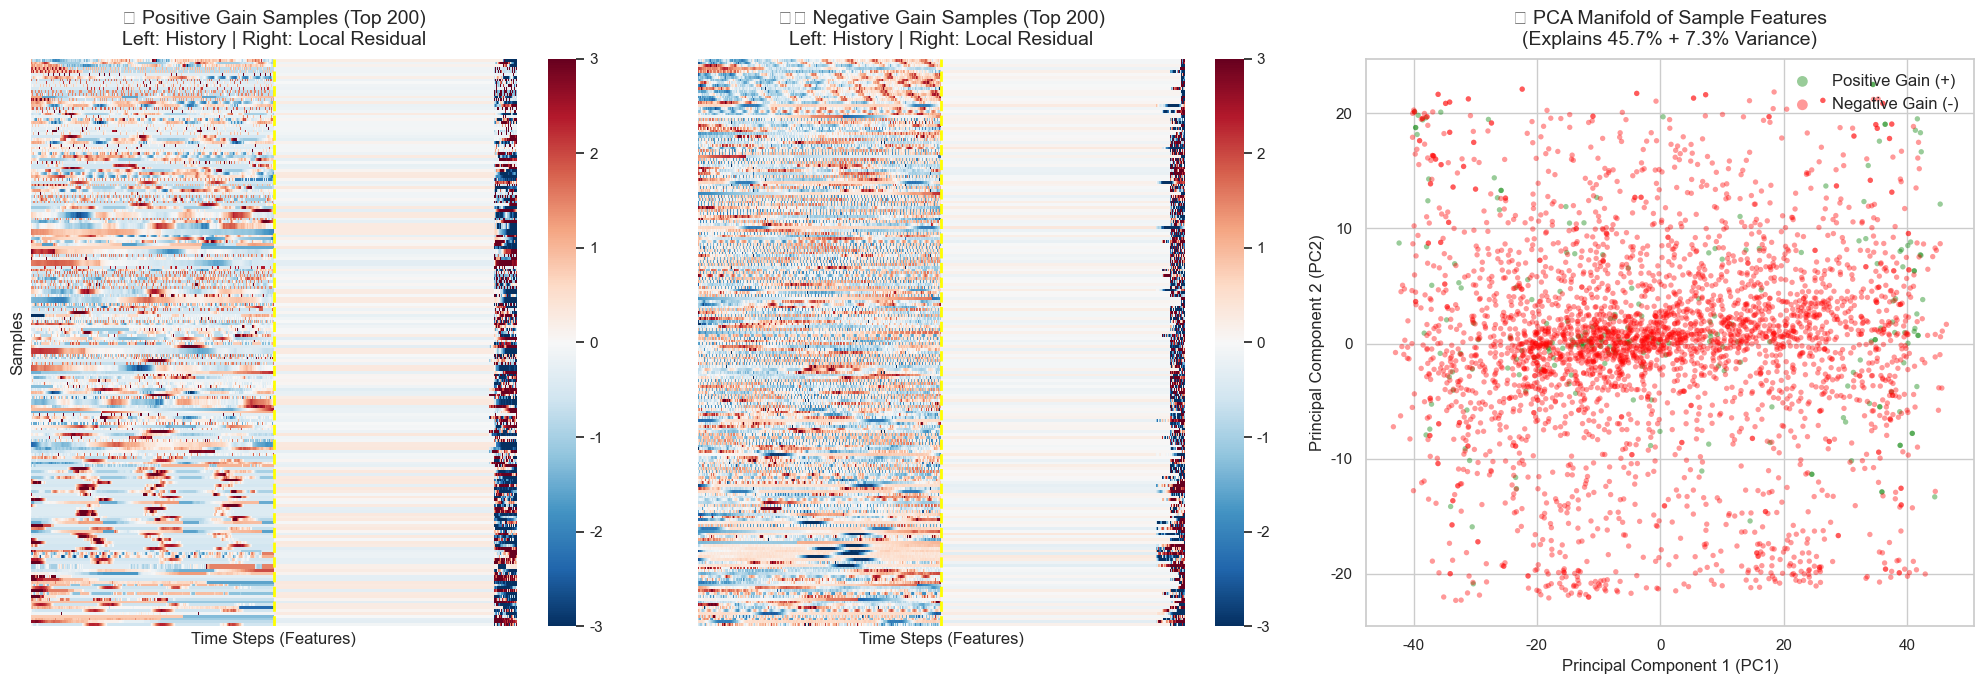

In [15]:
# 假设您已经从模型输出或 DataLoader 中收集到了以下列表，并转成了 numpy array
# hist_array.shape = (N, context_len)
# local_res_array.shape = (N, context_len)
# base_smape.shape = (N,)
# model_smape.shape = (N,)
# 一键触发全流程：特征提取 -> sMAPE对比 -> 升维拼接 -> PCA降维图与热力图
H_feat, L_feat, B_err, M_err, pca_engine = extract_and_visualize_gain_patterns(
    trainer=trainer, 
    split='test', 
    top_n_heatmap=200
)